In [1]:
import os
import pandas as pd
import numpy as np

def make_binary(df):
    df['REASONb'] = np.where(df['REASON'] == 1, 1, 0)
    df = df.drop(['REASON'], axis=1)
    return df

cur_dir = os.getcwd()
data_path = os.path.join(cur_dir, '..', 'data', 'raw', 'missing_corrected.csv')

df = pd.read_csv(data_path)
df_b = make_binary(df)
df_b["REASONb"]

0          0
1          0
2          0
3          0
4          0
          ..
1394133    0
1394134    0
1394135    1
1394136    0
1394137    1
Name: REASONb, Length: 1394138, dtype: int64

In [2]:
from pathlib import Path

root = os.path.abspath(os.path.join(cur_dir, "..", ".."))
root = Path(root)
run_dir = root / "runs" / "20260602-004051__gin_forecast_joint_generative_outcome_aware_single_run__bs=128__lr=4.80e-04__seed=1__single" 
cached_prediction_path = run_dir / "cached_predictions"


In [3]:
import torch

gnn_val_joint = torch.load(cached_prediction_path / "gnn_val_joint.pt", weights_only=False)

df_b.iloc[gnn_val_joint["indices"]]
df_b["CASEID"].loc[gnn_val_joint["indices"]]


1089093     427667
557108      961582
1345587    1472582
579564      732860
1208047     131366
            ...   
188741     1227520
1270928     909808
1336501     991599
1205539     125600
1352793    1429606
Name: CASEID, Length: 111531, dtype: int64

In [4]:
import pandas as pd
val_predictions_path = run_dir / "joint_predictor" / "val_predictions.csv"

val_predictions = pd.read_csv(val_predictions_path)
val_predictions

,row_idx,true_SERVICES_D,pred_SERVICES_D,true_EMPLOY_D,pred_EMPLOY_D,true_LIVARAG_D,pred_LIVARAG_D,true_ARRESTS_D,pred_ARRESTS_D,true_DETNLF_D,...,true_FREQ1_D,pred_FREQ1_D,true_FREQ2_D,pred_FREQ2_D,true_FREQ3_D,pred_FREQ3_D,true_FREQ_ATND_SELF_HELP_D,pred_FREQ_ATND_SELF_HELP_D,true_los,pred_los
0,292659,6,6,2,2,3,3,1,1,0,...,2,1,0,0,0,0,2,0,32,5
1,921609,6,6,1,1,3,3,1,1,0,...,3,3,0,0,0,0,1,1,1,0
2,1323616,6,6,3,3,0,0,1,1,0,...,1,1,0,0,0,0,1,1,32,5
3,703189,1,1,3,3,1,1,1,1,0,...,1,1,0,0,0,0,1,1,1,1
4,1066487,6,6,2,2,3,3,1,1,0,...,2,1,2,2,0,0,5,1,32,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111526,512159,6,6,1,1,3,3,1,1,0,...,2,2,2,2,3,3,1,1,36,5
111527,1207937,6,6,1,1,3,3,1,1,0,...,1,0,2,2,1,0,1,0,36,5
111528,1385153,5,5,0,0,0,0,0,0,0,...,1,1,0,0,1,1,1,1,34,5
111529,902803,6,6,3,3,3,3,1,1,0,...,2,2,0,0,3,3,1,1,35,0


In [5]:
x = val_predictions["true_SERVICES_D"].unique()
x.sort()
x

array([0, 1, 2, 3, 4, 5, 6, 7])

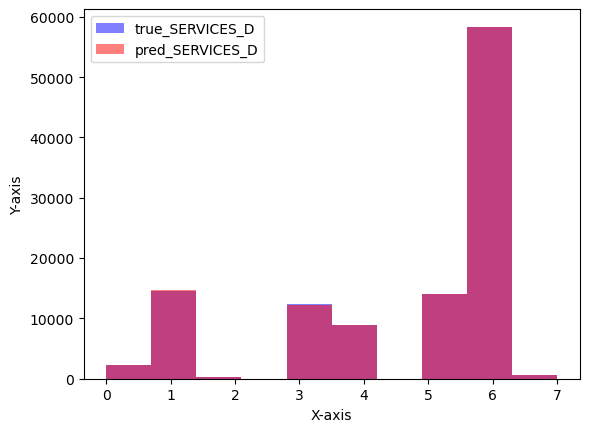

In [6]:
import matplotlib.pyplot as plt
# 데이터 생성
x = val_predictions["true_SERVICES_D"].unique()
x.sort()
y1 = val_predictions["true_SERVICES_D"]
y2 = val_predictions["pred_SERVICES_D"]

# 1. 그래프 겹쳐 그리기
plt.hist(y1, label='true_SERVICES_D', color='blue', alpha=0.5)
plt.hist(y2, label='pred_SERVICES_D', color='red', alpha=0.5)

# 2. 범례 및 레이블 추가
plt.legend()          # 범례 표시
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.show()

pred_los_type: coarse
True_los_type: raw37
pred_los_type: coarse
True_los_type: raw37


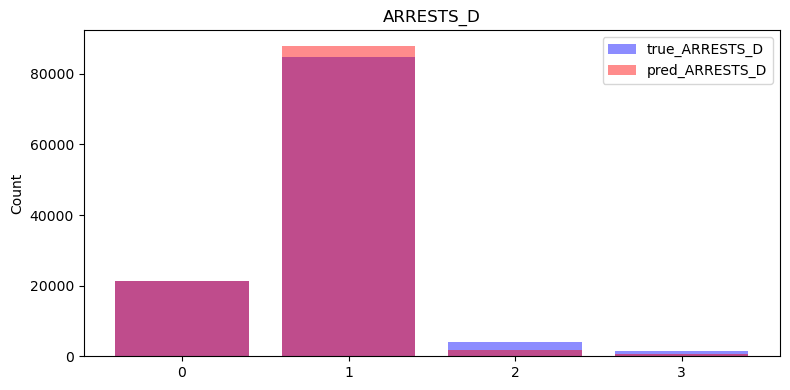

pred_los_type: coarse
True_los_type: raw37


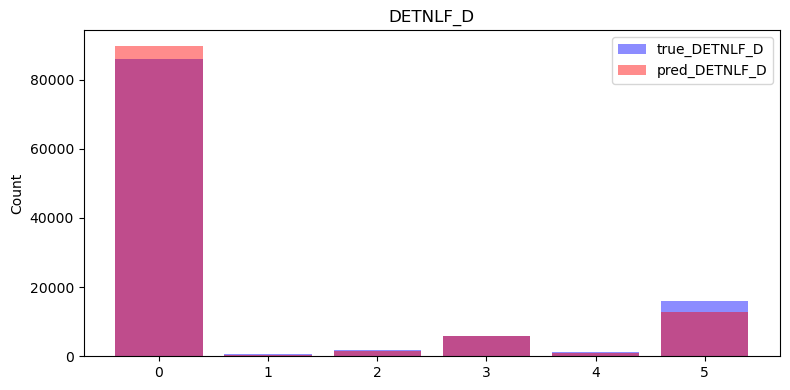

pred_los_type: coarse
True_los_type: raw37


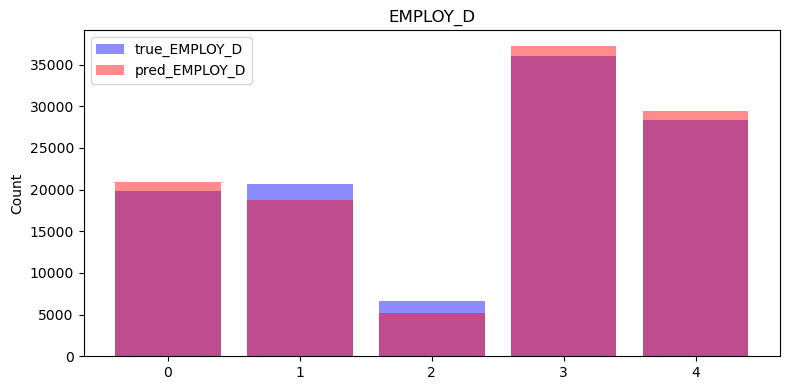

pred_los_type: coarse
True_los_type: raw37


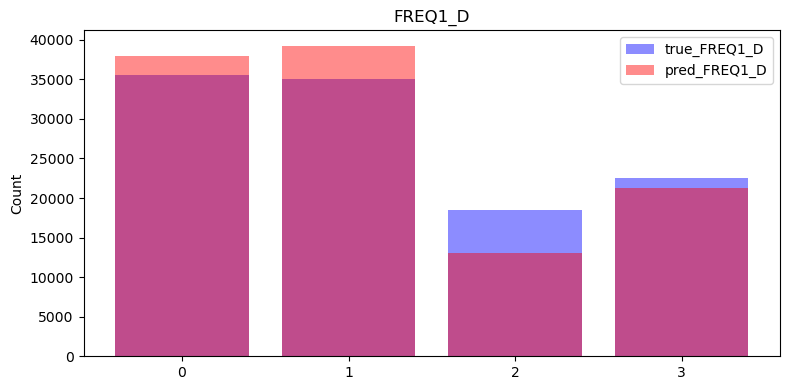

pred_los_type: coarse
True_los_type: raw37


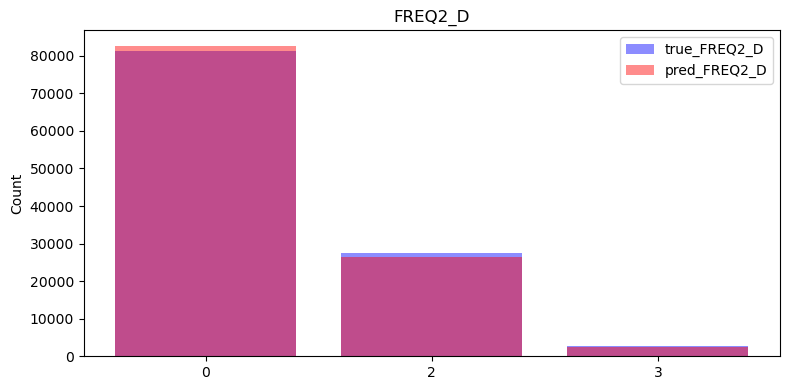

pred_los_type: coarse
True_los_type: raw37


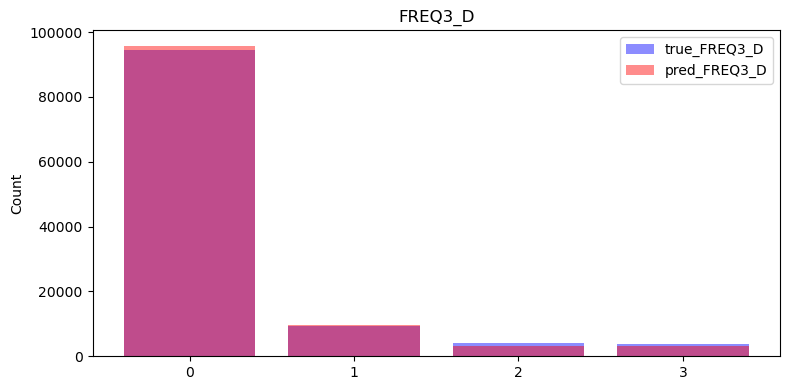

pred_los_type: coarse
True_los_type: raw37


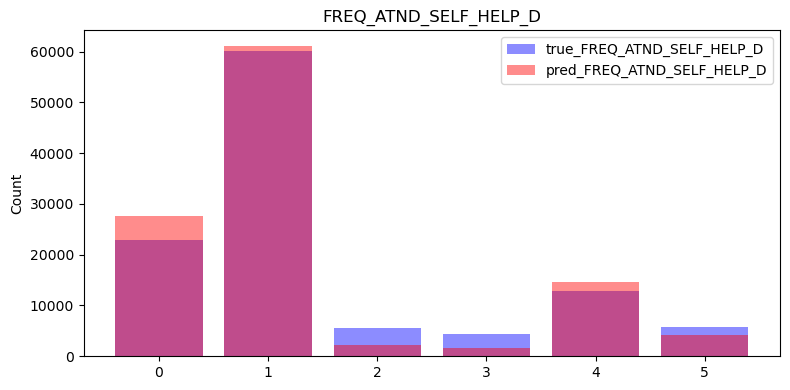

pred_los_type: coarse
True_los_type: raw37


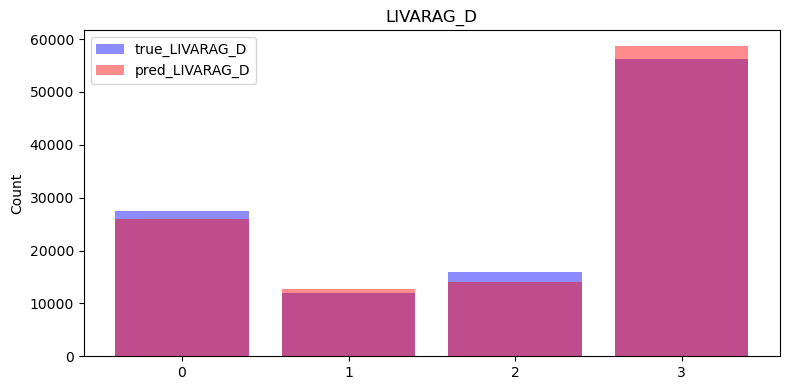

pred_los_type: coarse
True_los_type: raw37


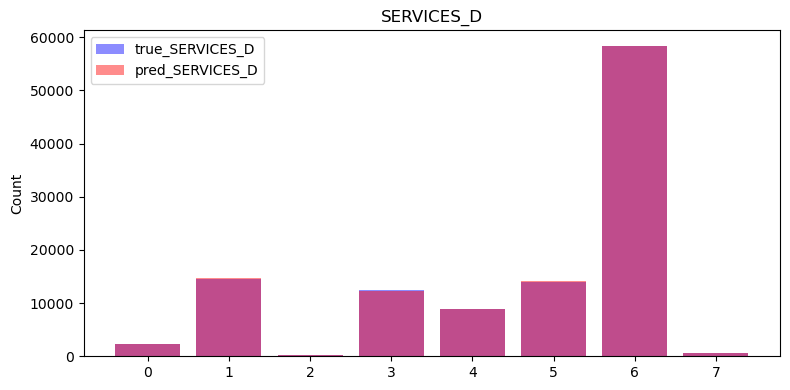

pred_los_type: coarse
True_los_type: raw37


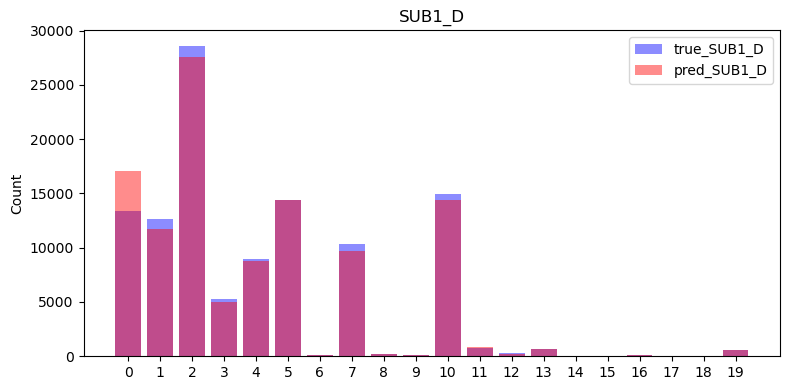

pred_los_type: coarse
True_los_type: raw37


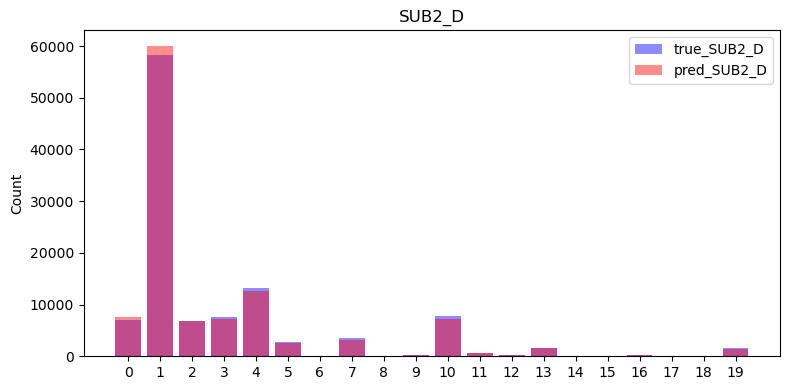

pred_los_type: coarse
True_los_type: raw37


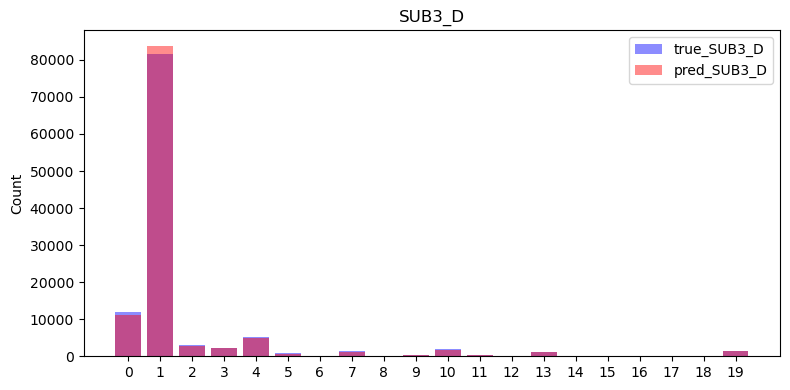

pred_los_type: coarse
True_los_type: raw37


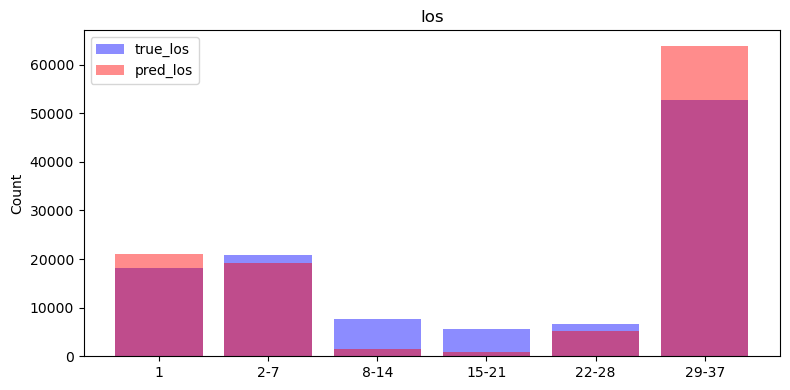

In [7]:
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

def map_los_to_coarse_bin(los: int) -> int:
    """Map a LOS value to one of six coarse duration bins.

    Args:
        los: Raw LOS codebook value in 1..37.

    Returns:
        Coarse class index in [0, 5].
    """
    raw_los = int(los)
    if raw_los < 1 or raw_los > 37:
        raise ValueError(f"LOS must be a raw codebook value in 1..37, got {los}.")
    if raw_los == 1:
        return 0
    if 2 <= raw_los <= 7:
        return 1
    if 8 <= raw_los <= 14:
        return 2
    if 15 <= raw_los <= 21:
        return 3
    if 22 <= raw_los <= 28:
        return 4
    if 29 <= raw_los <= 37:
        return 5
    raise ValueError(f"LOS must be in 1..37 after decoding, got {raw_los}.")

def map_los_array_to_coarse_bins(values, *, assume_encoded: bool = False) -> np.ndarray | torch.Tensor:
    """Vectorized LOS-to-coarse-bin mapping for NumPy, pandas, or PyTorch inputs."""
    def _map_value(value: int) -> int:
        raw_value = int(value) + 1 if assume_encoded else int(value)
        return map_los_to_coarse_bin(raw_value)

    if isinstance(values, torch.Tensor):
        arr = values.detach().cpu().numpy()
        mapped = np.vectorize(_map_value, otypes=[np.int64])(arr)
        return torch.as_tensor(mapped, dtype=torch.long, device=values.device)

    if isinstance(values, pd.Series):
        arr = values.to_numpy()
        return pd.Series(np.vectorize(_map_value, otypes=[np.int64])(arr), index=values.index)

    arr = np.asarray(values)
    return np.vectorize(_map_value, otypes=[np.int64])(arr)

def _resolve_run_dir(run_name: str):
    cur_dir = os.getcwd()
    root = os.path.abspath(os.path.join(cur_dir, "..", ".."))
    root = Path(root)
    run_dir = root / "runs" / run_name 
    return run_dir

def _get_los_target_mode(run_dir: Path) -> str | None:
    config_path = run_dir / "config.final.yaml"
    if not config_path.exists():
        return None

    with open(config_path, "r") as f:
        cfg = yaml.safe_load(f) or {}

    candidates = [
        cfg.get("los_target_mode"),
        cfg.get("joint_predictor", {}).get("los_target_mode"),
        cfg.get("forecasted_los", {}).get("target_mode"),
        cfg.get("joint_forecast_pipeline", {})
        .get("stage1", {})
        .get("joint_predictor", {})
        .get("los_target_mode"),
    ]
    for target_mode in candidates:
        if target_mode in {"raw37", "coarse"}:
            return target_mode
    return None

def _get_predictions_df(run_name):
    run_dir = _resolve_run_dir(run_name)

    if os.path.exists(run_dir / "val_predictions.csv"): 
        pred_path = run_dir /  "val_predictions.csv"

    elif os.path.exists(run_dir / "joint_predictor" / "val_predictions.csv"): 
        pred_path = run_dir / "joint_predictor" / "val_predictions.csv"
    
    elif os.path.exists(run_dir / "folds" / "fold_0" / "joint_predictor" / "val_predictions.csv"):
        pred_path = run_dir / "folds" / "fold_0" / "joint_predictor" / "val_predictions.csv"

    else:
        raise ValueError("Invalid run dir")
    
    df = pd.read_csv(pred_path)
    df.attrs["run_dir"] = str(run_dir)
    df.attrs["los_target_mode"] = _get_los_target_mode(run_dir)
    return df
    
def _get_variable_names(df: pd.DataFrame):
    var_names = set()
    for col in df.columns:
        if col.startswith("true_"):
            var = col[5:]
            if f"pred_{var}" in df.columns:
                var_names.add(var)
    return sorted(var_names)

def _check_los_type(los: pd.Series, *, target_mode: str | None = None):
    values = set(los.dropna().astype(int).unique())
    if target_mode == "raw37":
        return "raw37"
    if values <= set(range(6)):
        return "coarse"
    if values <= set(range(1, 38)):
        return "raw37"
    raise ValueError(f"unknown LOS label space: {sorted(values)}")

def _make_raw37_to_coarse(predictions_df: pd.DataFrame): 
    raw_los = predictions_df["true_los"]
    coarse_los = map_los_array_to_coarse_bins(raw_los)
    if "true_los" not in predictions_df.columns:
        raise ValueError("no true los in this df")
    new_df = predictions_df.drop("true_los", axis=1)
    new_df["true_los"] = coarse_los
    return new_df
     
def _make_los_type_identical(predictions_df: pd.DataFrame):
    new_df = predictions_df.copy()

    target_mode = predictions_df.attrs.get("los_target_mode")
    pred_los_type = _check_los_type(new_df["pred_los"], target_mode=target_mode)
    true_los_type = _check_los_type(new_df["true_los"])

    if pred_los_type != true_los_type:
        if pred_los_type == "coarse":
            new_df["true_los"] = map_los_array_to_coarse_bins(new_df["true_los"])
        else:
            raise ValueError("cannot make coarse true los into raw37 true los")
    return new_df, pred_los_type, true_los_type



def _create_comparing_hist(df, var):
    # coarse 변환 실제 적용
    df, pred_los_type, true_los_type = _make_los_type_identical(df)
    print("pred_los_type:", pred_los_type)
    print("True_los_type:", true_los_type)

    true_var = "true_" + var
    pred_var = "pred_" + var

    y_true = df[true_var].astype(int)
    y_pred = df[pred_var].astype(int)

    if var == "los":
        if pred_los_type == "coarse":
            classes = [0, 1, 2, 3, 4, 5]
            labels = ["1", "2-7", "8-14", "15-21", "22-28", "29-37"]
        else:
            classes = sorted(set(y_true.unique()) | set(y_pred.unique()))
            labels = [str(c) for c in classes]
    else:
        classes = sorted(set(y_true.unique()) | set(y_pred.unique()))
        labels = [str(c) for c in classes]

    true_counts = y_true.value_counts().reindex(classes, fill_value=0)
    pred_counts = y_pred.value_counts().reindex(classes, fill_value=0)

    x = np.arange(len(classes))

    plt.figure(figsize=(8, 4))

    # 같은 x 위치에 겹쳐서 그림
    plt.bar(
        x,
        true_counts.values,
        width=0.8,
        label=true_var,
        color="blue",
        alpha=0.45,
    )
    plt.bar(
        x,
        pred_counts.values,
        width=0.8,
        label=pred_var,
        color="red",
        alpha=0.45,
    )

    plt.xticks(x, labels)
    plt.ylabel("Count")
    plt.title(var)
    plt.legend()
    plt.tight_layout()
    plt.show()

def show_comparing_hist(run_name, var):
    df = _get_predictions_df(run_name)
    _create_comparing_hist(df, var)

def show_all_comparing_hist(run_name: str):
    df = _get_predictions_df(run_name)

    # coarse 변환 실제 적용
    df, pred_los_type, true_los_type = _make_los_type_identical(df)
    print("pred_los_type:", pred_los_type)
    print("True_los_type:", true_los_type)

    var_names = _get_variable_names(df)

    for var in var_names:
        show_comparing_hist(run_name, var)

run_name = "20260602-004051__gin_forecast_joint_generative_outcome_aware_single_run__bs=128__lr=4.80e-04__seed=1__single"
show_all_comparing_hist(run_name)


In [8]:
def _get_metric_per_class(true_series: pd.Series, pred_series: pd.Series, threshold: float = 0.1):
    true_series = pd.Series(true_series).reset_index(drop=True)
    pred_series = pd.Series(pred_series).reset_index(drop=True)

    if len(true_series) != len(pred_series):
        raise ValueError("true_series와 pred_series의 길이가 다릅니다.")

    result = []

    for cls in sorted(true_series.unique()):
        mask = true_series == cls

        support = mask.sum()
        correct = (pred_series[mask] == true_series[mask]).sum()
        accuracy = correct / support if support > 0 else float("nan")
        intensity = "*" if accuracy < threshold else ""

        result.append(
            {
                "class": cls,
                "support": support,
                "correct": correct,
                "los_predictor_accuracy": accuracy,
                f"acc < {threshold}": intensity,
                
            }
        )

    return pd.DataFrame(result).set_index("class")


def get_LOS_metric_per_class(run_name: str):
    predictions_df = _get_predictions_df(run_name)
    predictions_df, pred_los_type, true_los_type = _make_los_type_identical(predictions_df)
    print("pred_los_type:", pred_los_type)
    print("True_los_type:", true_los_type)
    true_series = predictions_df["true_los"]
    pred_series = predictions_df["pred_los"]
    return _get_metric_per_class(true_series, pred_series)    

pred_los_type: raw37
True_los_type: raw37


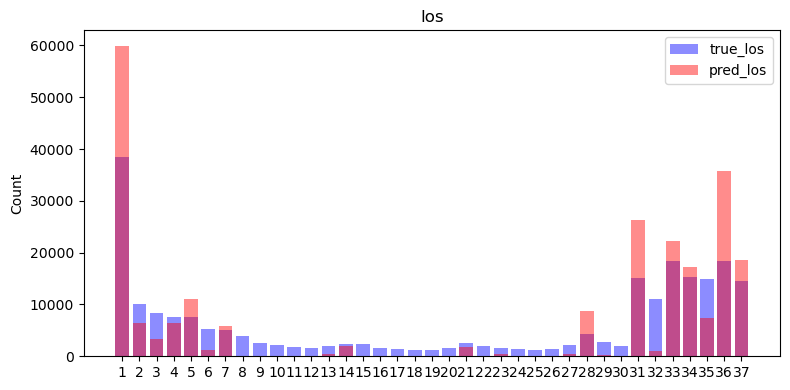

pred_los_type: raw37
True_los_type: raw37


,support,correct,los_predictor_accuracy,acc < 0.1
class,,,,
1,38489,32028,0.832134,
2,10064,2172,0.215819,
3,8326,937,0.112539,
4,7597,1659,0.218376,
5,7561,2714,0.358947,
6,5345,318,0.059495,*
7,5156,1152,0.223429,
8,3853,0,0.000000,*
9,2483,0,0.000000,*


In [9]:
# raw37
show_comparing_hist("20260517-102430__joint_consistent_predictor__bs=1024__lr=1.00e-03__seed=1", "los")
get_LOS_metric_per_class("20260517-102430__joint_consistent_predictor__bs=1024__lr=1.00e-03__seed=1")

20260519-030905__ctmp_gin_joint_fresh_id22__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2_lambda=0.3
pred_los_type: coarse
True_los_type: raw37


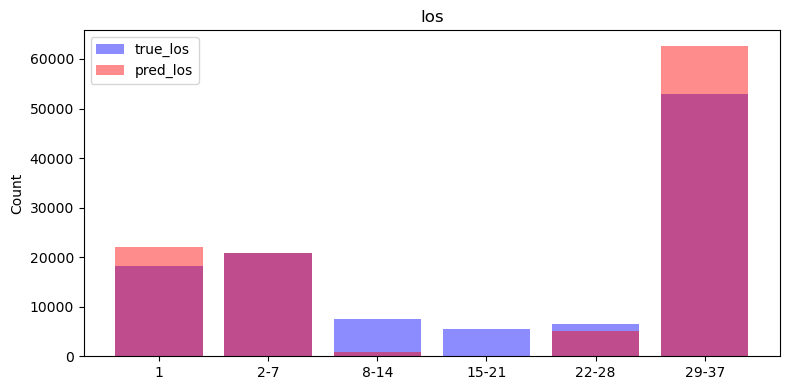

pred_los_type: coarse
True_los_type: raw37
       support  correct  los_predictor_accuracy acc < 0.1
class                                                    
0        18142    13481                0.743082          
1        20756    14109                0.679755          
2         7556      281                0.037189         *
3         5602       11                0.001964         *
4         6604     1877                0.284222          
5        52871    46796                0.885098          
20260519-030924__ctmp_gin_joint_fresh_id9__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2
pred_los_type: coarse
True_los_type: raw37


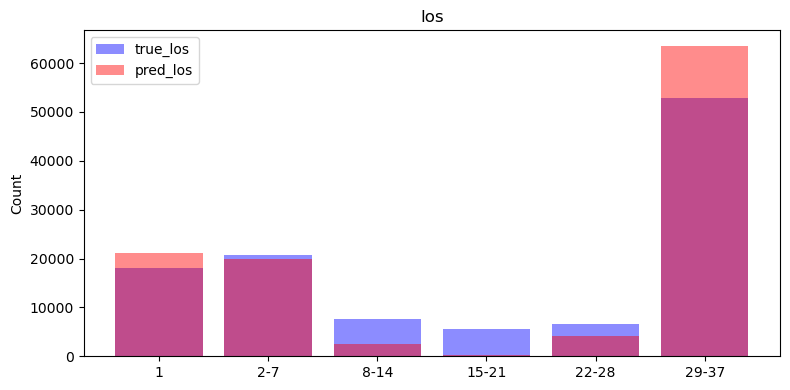

pred_los_type: coarse
True_los_type: raw37
       support  correct  los_predictor_accuracy acc < 0.1
class                                                    
0        18142    13083                0.721144          
1        20756    13847                0.667132          
2         7556      612                0.080995         *
3         5602       93                0.016601         *
4         6604     1534                0.232283          
5        52871    46972                0.888427          
20260519-041725__ctmp_gin_joint_fresh_id26__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2_lambda=0.3
pred_los_type: coarse
True_los_type: raw37


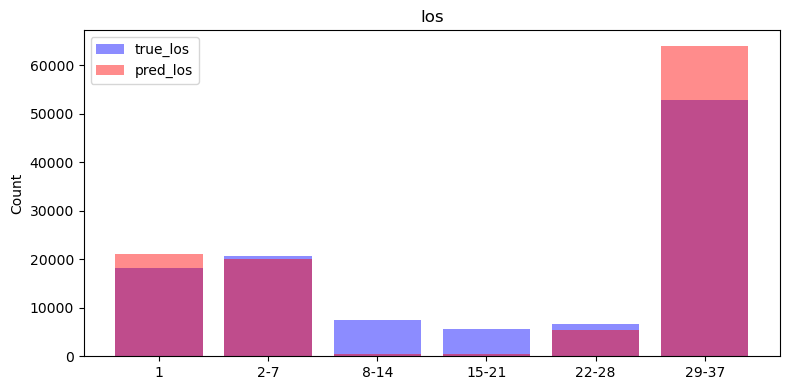

pred_los_type: coarse
True_los_type: raw37
       support  correct  los_predictor_accuracy acc < 0.1
class                                                    
0        18142    13038                0.718664          
1        20756    13842                0.666892          
2         7556      192                0.025410         *
3         5602      133                0.023742         *
4         6604     1850                0.280133          
5        52871    47108                0.890999          
20260519-153542__ctmp_gin_joint_fresh_id38__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2_lambda=0.3
pred_los_type: coarse
True_los_type: raw37


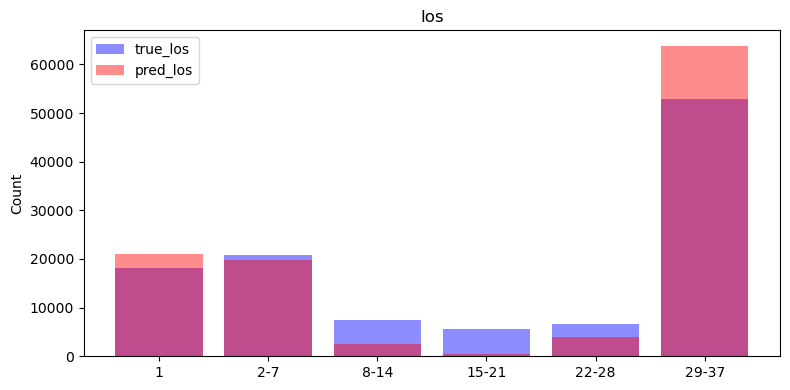

pred_los_type: coarse
True_los_type: raw37
       support  correct  los_predictor_accuracy acc < 0.1
class                                                    
0        18142    13079                0.720924          
1        20756    13842                0.666892          
2         7556      615                0.081392         *
3         5602      127                0.022670         *
4         6604     1437                0.217595          
5        52871    47049                0.889883          
20260528-232514__ctmp_gin_joint_generative_coarse_distribution__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2
pred_los_type: coarse
True_los_type: raw37


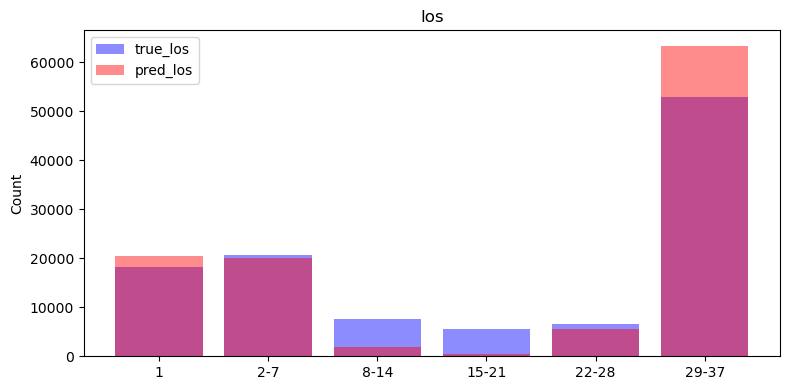

pred_los_type: coarse
True_los_type: raw37
       support  correct  los_predictor_accuracy acc < 0.1
class                                                    
0        18142    13001                0.716624          
1        20756    13992                0.674118          
2         7556      577                0.076363         *
3         5602      165                0.029454         *
4         6604     2053                0.310872          
5        52871    47160                0.891982          


In [10]:
check_list = [
    "20260519-030905__ctmp_gin_joint_fresh_id22__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2_lambda=0.3",
    "20260519-030924__ctmp_gin_joint_fresh_id9__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2",
    "20260519-041725__ctmp_gin_joint_fresh_id26__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2_lambda=0.3",
    "20260519-153542__ctmp_gin_joint_fresh_id38__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2_lambda=0.3",
    "20260528-232514__ctmp_gin_joint_generative_coarse_distribution__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2"
]

for run_name in check_list:
    print(run_name)
    show_comparing_hist(run_name, "los")
    print(get_LOS_metric_per_class(run_name))

만약 forecasted gnn이 희소 los에서 특히 성능이 떨어진다면, 원인은 희소 los 케이스에 대한 예측력 부족이라고 할 수 있음

여태까지 joint consistency만을 생각해왔음
하지만 joint consistency에서 가장 큰 문제가 되었던 변수들 (SERVICES_D)는 위의 히스토그램에 따르면 예측 성능이 오히려 다른 변수들 보다도 더 좋음
그런데 los에서 희소 클래스들에 대한 성능이 모델 구조, 하이퍼파라미터 세팅과 상관없이 일관적으로 낮게 나옴

joint distribution drift는 원인이 아니라 결과일 것이라는 해석을 할 수 있음

원래 해석은 다음과 같음
_D, LOS 둘 중 하나만이라도 oracle이라면 성능이 잘 나옴 (아마 이때 los는 raw37이었을 것으로 기억)
근데 둘이 같이 있으니까 성능이 급락

그 이유를 찾기 시작
1. _D predictor의 성능이 나쁘지 않다
2. LOS predictor의 성능도 나쁘지 않다
근데 이 둘이 같이 있을 때 문제가 생김

그렇다면 _D predictor와 LOS predictor가 각각 독립적으로 예측을 하고 있기 때문에 발생하는 문제인 것 아닌가?
-> (true_D | true_LOS) <-> (pred_D | pred_LOS)의 차이를 구했을 때 drift가 있는 것으로 나옴
-> 아 이게 문제구나.

라는 논리로 진행했던 것임

하지만 가설과 증거 사이의 간극이 충분히 있을 수 있음
[지금까지의 논리]
(가설) A이면 B이다. / B이면 성능이 안 나온다. / B가 사실이다. / 그러므로 A가 사실이다. 

-> 근데 이런 함정이 있을 수도 있음
1. B여도 성능이 잘 나올 수 있음
2. B가 사실이긴 해도, 그 실질적인 원인은 A가 아닌 C일 수 있음.

가능한 C들:
하지만 애초에 pred_LOS 자체를 틀려버리면? 애초에 pred_D 자체를 틀려버린다면?
특히 LOS를 예측하는 데 희귀 클래스에서 성능이 매우 안 좋게 나온다면?
그렇기 때문에 (true_D | true_LOS) <-> (pred_D | pred_LOS)의 차이가 생기는 것이라면?

-> 이렇게 생각한 이유는 drift가 가장 큰 변수로 SERVICES_D가 나오는데, _D predictor에서 SERVICED_D의 성능은 oracle에 가깝다.
-> 즉 pred_LOS가 무너졌기 때문에서 (true_D | true_LOS) <-> (pred_D | pred_LOS) drift가 발생하는 것.


앞으로의 방향: 문제를 간단하게 생각하자.

현재까지 알아낸 사실:
1. _D predictor의 성능이 나쁘지 않다
2. LOS predictor의 성능도 나쁘지 않다

_D, LOS 둘 중 하나만이라도 oracle이라면 성능이 잘 나옴 (아마 이때 los는 raw37이었을 것으로 기억)
근데 둘이 같이 있으니까 성능이 급락

그렇다면 이 둘 중 하나만이라도 oracle에 근접하게 성능을 낼 수 있다면?
성능이 오를 수 있다.


1. 정말로 희귀 클래스에서 성능이 안 좋게 나오는지 분석
    - id 22, 26 등 다운스트림까지 간 joint predictor 들에세거 pred_LOS의 성능을 클래스별로 측정
    - forecasted GNN의 성능을 pred_LOS 클래스별로 측정
    - 특히 forecasted GNN의 성능이 희소 LOS 클래스에서 확연하게 떨어진다면, good, 이걸 맞출 수 있다면 성능이 올라갈 가능성이 있음
2. 해결 방안: DATA augmentation
    희소 클래스들에 대한 데이터 증강

In [11]:
import os
import sys
import yaml
import torch
from pathlib import Path

cur_dir = os.getcwd()
root = os.path.abspath(os.path.join(cur_dir, "..", ".."))
sys.path.append(root)

from src.models.discharge_predictor import joint_consistent_predictor
from src.models.ctmp_gin import CTMPGIN

from src.trainers.run_joint_consistent_predictor import JointPredictionDataset, JointPredictionBatch


check_list = [
    "20260519-030905__ctmp_gin_joint_fresh_id22__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2_lambda=0.3",
    "20260519-030924__ctmp_gin_joint_fresh_id9__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2",
    "20260519-041725__ctmp_gin_joint_fresh_id26__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2_lambda=0.3",
    "20260519-153542__ctmp_gin_joint_fresh_id38__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2_lambda=0.3",
    "20260528-232514__ctmp_gin_joint_generative_coarse_distribution__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2"
]



/opt/miniconda3/envs/pyg_2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:

def load_joint_cache(run_name, mode = "joint_cache"):
    run_dir = _resolve_run_dir(run_name)
    if mode == "joint_cache":
        val_cache_path = run_dir / "folds" / "fold_0" / "joint_predictor" / "joint_cache" / "gnn_val.pt"
        test_cache_path = run_dir / "folds" / "fold_0" / "joint_predictor" / "joint_cache" / "outer_test.pt" 
    
    elif mode == "cached_predictions":
        val_cache_path = run_dir / "folds" / "fold_0" / "cached_predictions" / "gnn_val_joint.pt"
        test_cache_path = run_dir / "folds" / "fold_0" / "cached_predictions" / "outer_test_joint.pt" 
    
    else:
        raise ValueError(f"Invalid mode. Only \"joint_cache\" or \"cached_predictions\" Got {mode}")

    for path in (val_cache_path, test_cache_path):
        if not os.path.exists(path):
            raise ValueError(f"{path} does not exists")
        
    val_predictions = torch.load(val_cache_path, weights_only=False)
    test_predictions = torch.load(test_cache_path, weights_only=False)

    return val_predictions, test_predictions

val_predictions, test_predictions = load_joint_cache(check_list[2], mode="cached_predictions")

In [13]:
val_cache_path, test_cache_path = load_joint_cache(check_list[2], mode="joint_cache")
gnn_val_joint, outer_test_joint = load_joint_cache(check_list[2], mode="cached_predictions")

In [14]:
val_cache_path

{'split': 'gnn_val',
 'final_d_logits': {'SERVICES_D': tensor([[ -2.7353,  -1.4580,  -3.5334,  ...,  -3.7258,   3.5230,  -9.7781],
          [ -8.9759, -10.0650,  -8.7721,  ...,  -3.8835,   6.6601,  -9.9552],
          [-17.1964,  -9.4200,  -5.5544,  ...,  10.7257,  -1.8813, -13.3580],
          ...,
          [ -4.3776,  -4.2256,  -4.4456,  ...,   1.0545,  -2.1507,  -5.8332],
          [ -6.7982,  -6.4497,  -7.8406,  ...,  -3.1087,   6.6736, -10.3729],
          [ -3.5461,  -1.7973,  -4.0118,  ...,  -2.6999,   3.7294, -10.8195]]),
  'EMPLOY_D': tensor([[ 1.3442,  0.4452, -0.2600, -7.1700,  1.3746],
          [-1.7682, -0.8656, -1.2178, -0.2125,  2.2655],
          [-7.5503, -3.1672, -3.4858,  5.6590, -4.8971],
          ...,
          [-0.8388, -0.8986, -1.2301,  1.6417, -1.2341],
          [-0.2227, -1.0146, -1.7503, -0.0685,  1.5539],
          [ 1.8927,  0.2479, -0.8450, -6.0288,  0.7551]]),
  'LIVARAG_D': tensor([[ 8.8051, -3.9096, -3.4148, -2.0807],
          [-7.4982,  0.9766, -

In [15]:
gnn_val_joint

{'x': tensor([[  2,   0,   1,  ...,   0,   0,   0],
         [ 31,   2,   1,  ...,   1,   1,   7],
         [ 32,   2,   2,  ...,   2,   2, 240],
         ...,
         [ 22,   3,   2,  ...,   1,   1, 502],
         [ 24,   4,   1,  ...,   2,   2, 517],
         [  2,   0,   0,  ...,   0,   0, 198]]),
 'los': tensor([[0.4292, 0.0144, 0.0144,  ..., 0.0357, 0.0357, 0.0357],
         [0.0238, 0.0038, 0.0038,  ..., 0.0954, 0.0954, 0.0954],
         [0.8929, 0.0080, 0.0080,  ..., 0.0034, 0.0034, 0.0034],
         ...,
         [0.0158, 0.0161, 0.0161,  ..., 0.0686, 0.0686, 0.0686],
         [0.0054, 0.0051, 0.0051,  ..., 0.0974, 0.0974, 0.0974],
         [0.4609, 0.0133, 0.0133,  ..., 0.0360, 0.0360, 0.0360]]),
 'indices': array([  73325, 1142748,  816103, ...,  726344,  793388,   77405],
       shape=(111531,)),
 'soft_discharge': {'head_names': ['SERVICES_D',
   'EMPLOY_D',
   'LIVARAG_D',
   'ARRESTS_D',
   'DETNLF_D',
   'SUB1_D',
   'SUB2_D',
   'SUB3_D',
   'FREQ1_D',
   'FREQ2_D',
  

In [16]:
# Forecasted GNN baseline LOS-group metrics visualization
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

COARSE6_LABEL_ORDER = ['1', '2-7', '8-14', '15-21', '22-28', '29-37']

def resolve_forecasted_gnn_diag_dir(run_name: str, fold: int = 0) -> Path:
    run_dir = _resolve_run_dir(run_name)
    return run_dir / 'folds' / f'fold_{fold}' / 'diagnostics' / 'forecasted_gnn_performance'

def load_forecasted_gnn_group_metrics(run_name: str, fold: int = 0) -> pd.DataFrame:
    diag_dir = resolve_forecasted_gnn_diag_dir(run_name, fold=fold)
    df = pd.read_csv(diag_dir / 'los_group_metrics.csv')
    return df

def _ordered_group_df(df: pd.DataFrame, *, split: str, los_space: str) -> pd.DataFrame:
    out = df[(df['split'] == split) & (df['los_space'] == los_space)].copy()
    if los_space == 'coarse6':
        out['los_label_name'] = pd.Categorical(out['los_label_name'], categories=COARSE6_LABEL_ORDER, ordered=True)
        out = out.sort_values('los_label_name')
    else:
        out = out.sort_values('los_label')
    return out.reset_index(drop=True)

def plot_los_group_metric(df: pd.DataFrame, *, split: str, los_space: str, metric: str, min_support: int = 0, ax=None):
    plot_df = _ordered_group_df(df, split=split, los_space=los_space)
    plot_df = plot_df[plot_df['support'] >= min_support].copy()
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))
    colors = ['tab:red' if pd.isna(v) else 'tab:blue' for v in plot_df[metric]]
    ax.bar(plot_df['los_label_name'].astype(str), plot_df[metric].fillna(0.0), color=colors, alpha=0.8)
    ax.set_title(f'{split} | {los_space} | {metric}')
    ax.set_xlabel('LOS label')
    ax.set_ylabel(metric)
    ax.set_ylim(0.0, 1.05 if metric in {'accuracy', 'precision', 'recall', 'f1', 'auc'} else max(1.0, float(plot_df[metric].max())))
    ax.grid(axis='y', alpha=0.3)
    for idx, row in plot_df.reset_index(drop=True).iterrows():
        value = row[metric]
        label = 'NA' if pd.isna(value) else f'{value:.3f}'
        ax.text(idx, 0.01 if pd.isna(value) else float(value) + 0.02, label, ha='center', va='bottom', fontsize=8, rotation=90)
    return ax

def plot_los_group_acc_auc(df: pd.DataFrame, *, split: str, los_space: str, min_support: int = 0):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    plot_los_group_metric(df, split=split, los_space=los_space, metric='accuracy', min_support=min_support, ax=axes[0])
    plot_los_group_metric(df, split=split, los_space=los_space, metric='auc', min_support=min_support, ax=axes[1])
    axes[1].set_xlabel('LOS label')
    fig.tight_layout()
    return fig, axes

def plot_los_group_support(df: pd.DataFrame, *, split: str, los_space: str, ax=None):
    plot_df = _ordered_group_df(df, split=split, los_space=los_space)
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))
    ax.bar(plot_df['los_label_name'].astype(str), plot_df['support'], color='tab:gray', alpha=0.8)
    ax.set_title(f'{split} | {los_space} | support')
    ax.set_xlabel('LOS label')
    ax.set_ylabel('support')
    ax.grid(axis='y', alpha=0.3)
    return ax

def plot_split_comparison(df: pd.DataFrame, *, los_space: str, metric: str, min_support: int = 0):
    plot_df = df[df['los_space'] == los_space].copy()
    plot_df = plot_df[plot_df['support'] >= min_support].copy()
    if los_space == 'coarse6':
        order = COARSE6_LABEL_ORDER
    else:
        order = sorted(plot_df['los_label_name'].astype(str).unique(), key=lambda x: int(x))
    pivot = plot_df.pivot(index='split', columns='los_label_name', values=metric).reindex(columns=order)
    fig, ax = plt.subplots(figsize=(max(10, len(order) * 0.45), 3.5))
    for split_name, row in pivot.iterrows():
        ax.plot(pivot.columns.astype(str), row.values, marker='o', label=split_name)
    ax.set_title(f'{los_space} | {metric} split comparison')
    ax.set_xlabel('LOS label')
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig, ax


In [17]:
# Example: target run diagnostics load
run_name = '20260519-041725__ctmp_gin_joint_fresh_id26__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2_lambda=0.3'
group_metrics_df = load_forecasted_gnn_group_metrics(run_name, fold=0)
group_metrics_df.head()


,split,los_space,los_label,los_label_name,support,positive_count,negative_count,accuracy,precision,recall,f1,auc,tn,fp,fn,tp
0,gnn_val,coarse6,0,1,17998,6940,11058,0.924769,0.856523,0.966859,0.908353,0.986572,9934,1124,230,6710
1,gnn_val,coarse6,1,2-7,20777,9985,10792,0.780767,0.717165,0.897947,0.797439,0.890316,7256,3536,1019,8966
2,gnn_val,coarse6,2,8-14,7664,3190,4474,0.788753,0.702501,0.854232,0.770972,0.887307,3320,1154,465,2725
3,gnn_val,coarse6,3,15-21,5457,2193,3264,0.810335,0.731600,0.834017,0.779459,0.894285,2593,671,364,1829
4,gnn_val,coarse6,4,22-28,6627,3877,2750,0.826769,0.869283,0.828476,0.848389,0.902102,2267,483,665,3212


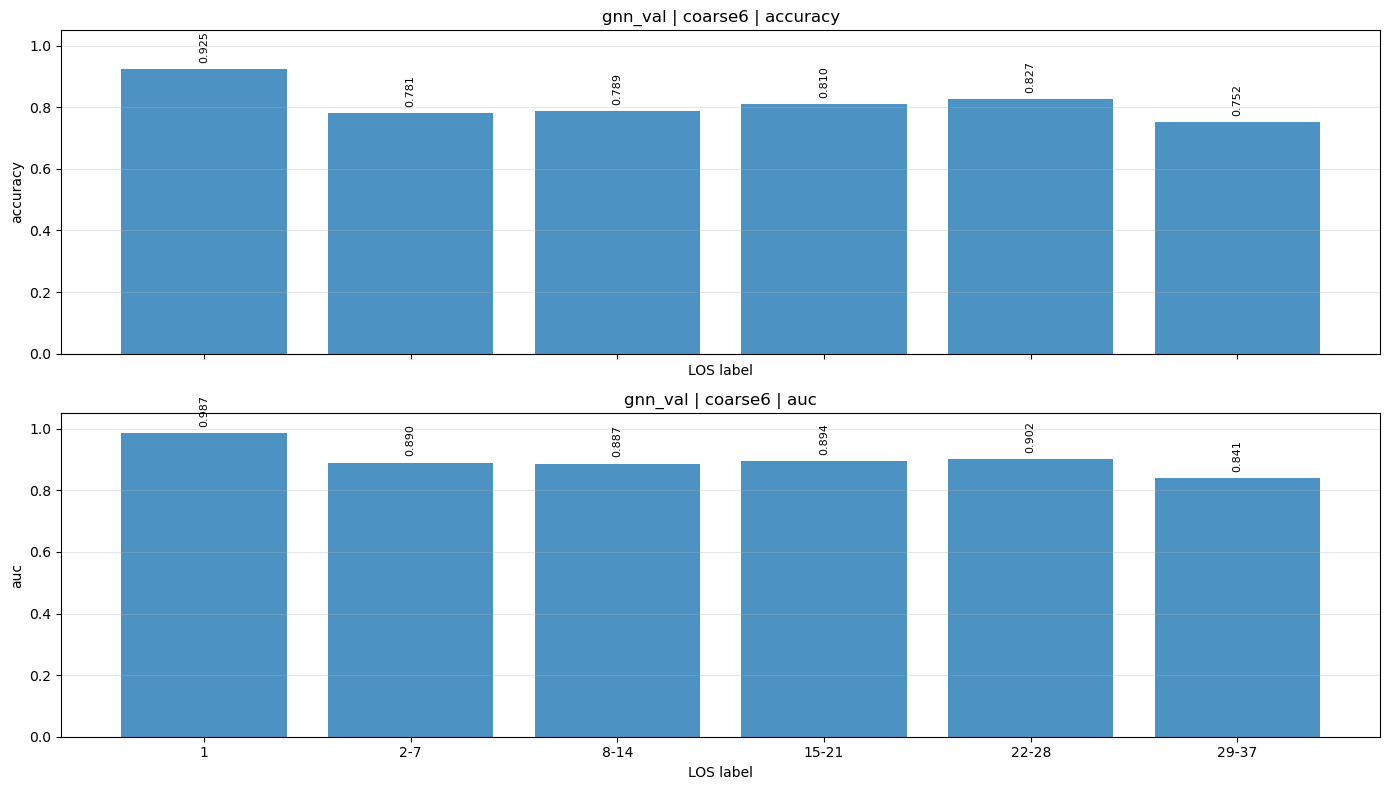

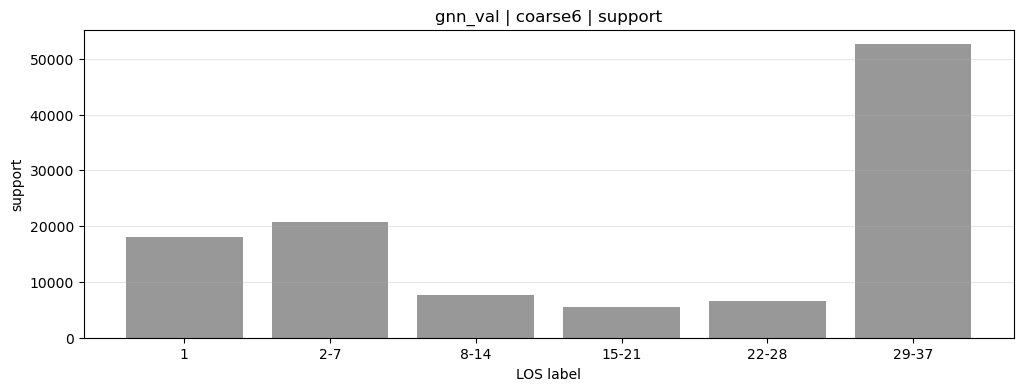

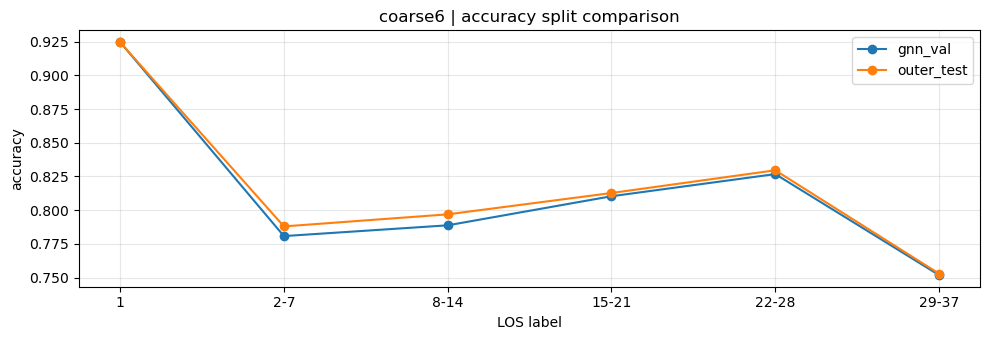

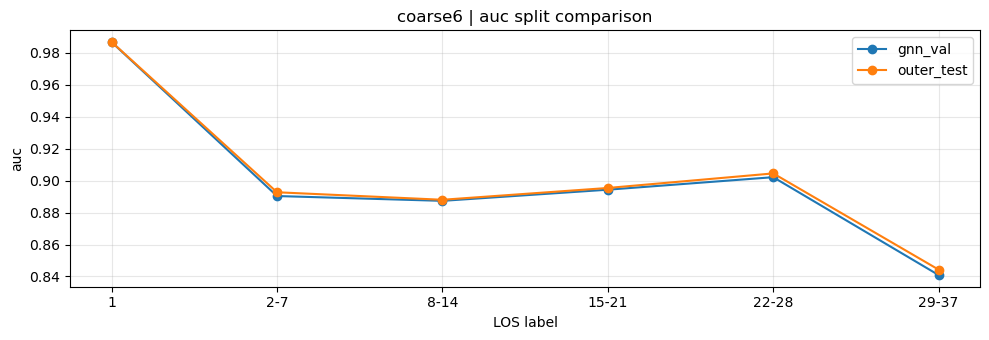

In [18]:
# Coarse6 visualization: accuracy / auc / support
plot_los_group_acc_auc(group_metrics_df, split='gnn_val', los_space='coarse6', min_support=0);
plot_los_group_support(group_metrics_df, split='gnn_val', los_space='coarse6');
plot_split_comparison(group_metrics_df, los_space='coarse6', metric='accuracy', min_support=0);
plot_split_comparison(group_metrics_df, los_space='coarse6', metric='auc', min_support=0);


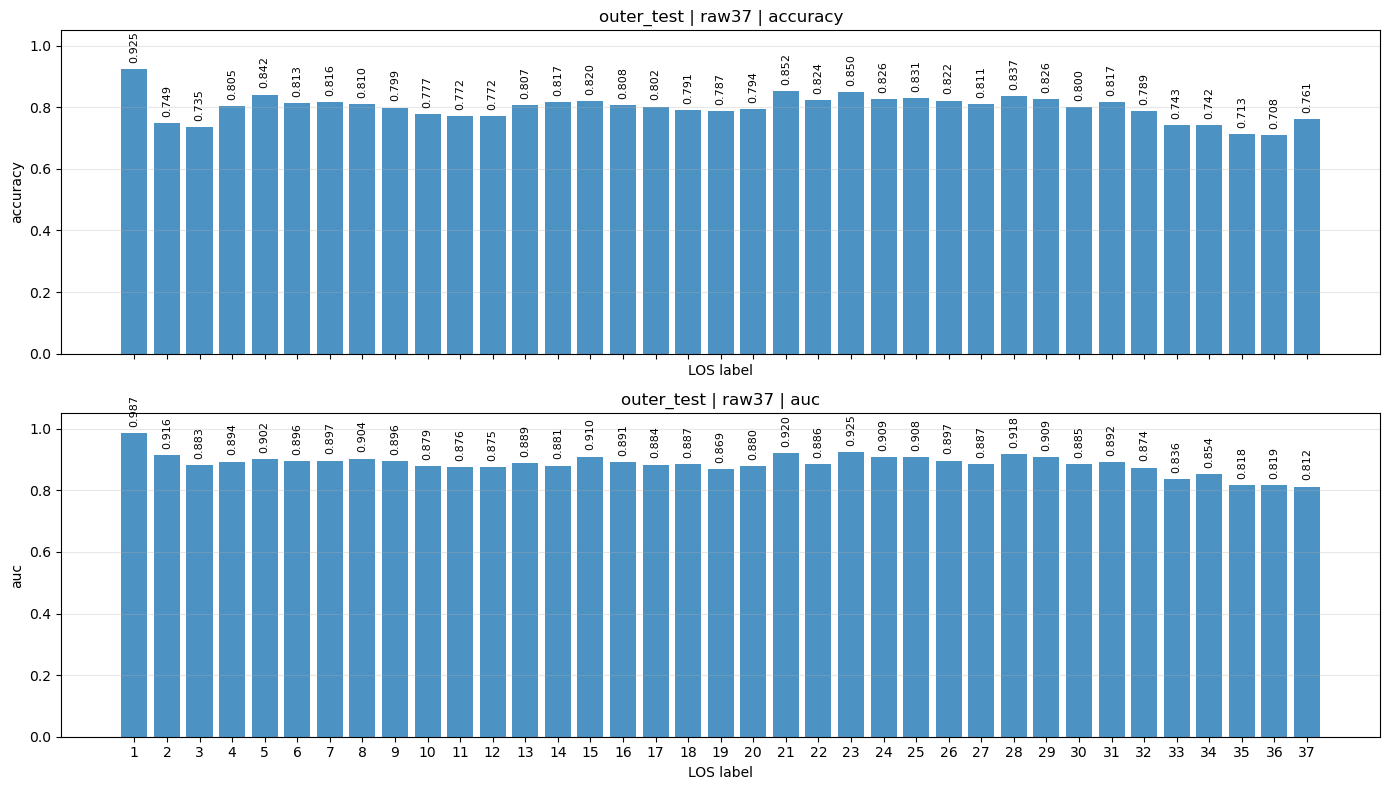

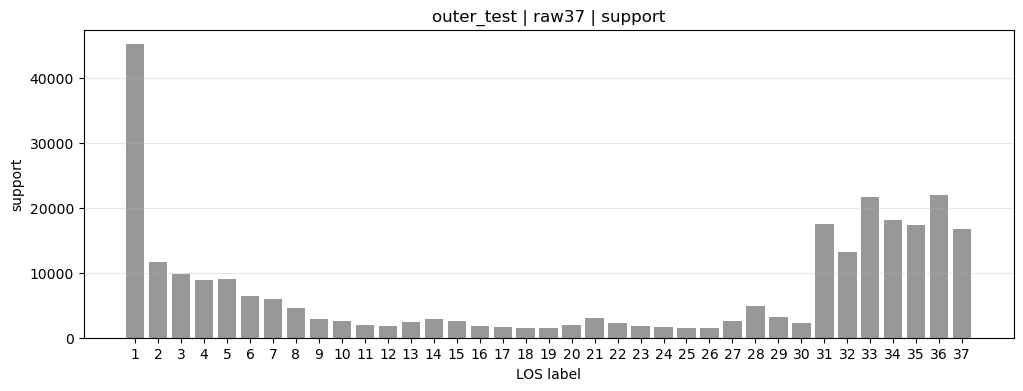

In [19]:
# Raw37 visualization: too many labels for all-at-once reading, so filter by support if needed
plot_los_group_acc_auc(group_metrics_df, split='outer_test', los_space='raw37', min_support=1000);
plot_los_group_support(group_metrics_df, split='outer_test', los_space='raw37');


run_name=20260519-041725__ctmp_gin_joint_fresh_id26__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2_lambda=0.3
[1] prediction histogram: true vs pred los
pred_los_type: coarse
True_los_type: raw37


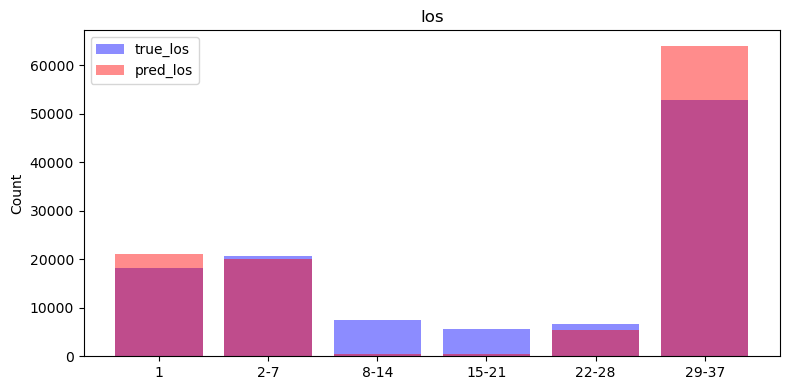

[2] LOS-group metrics table preview


,los_label_name,support,accuracy,auc,precision,recall,f1
0,1,17998,0.924769,0.986572,0.856523,0.966859,0.908353
1,2-7,20777,0.780767,0.890316,0.717165,0.897947,0.797439
2,8-14,7664,0.788753,0.887307,0.702501,0.854232,0.770972
3,15-21,5457,0.810335,0.894285,0.731600,0.834017,0.779459
4,22-28,6627,0.826769,0.902102,0.869283,0.828476,0.848389
5,29-37,52581,0.751850,0.840890,0.805895,0.575013,0.671153


[3] LOS-group accuracy / auc
[4] LOS-group support


,split,los_space,los_label,los_label_name,support,positive_count,negative_count,accuracy,precision,recall,f1,auc,tn,fp,fn,tp
0,gnn_val,coarse6,0,1,17998,6940,11058,0.924769,0.856523,0.966859,0.908353,0.986572,9934,1124,230,6710
1,gnn_val,coarse6,1,2-7,20777,9985,10792,0.780767,0.717165,0.897947,0.797439,0.890316,7256,3536,1019,8966
2,gnn_val,coarse6,2,8-14,7664,3190,4474,0.788753,0.702501,0.854232,0.770972,0.887307,3320,1154,465,2725
3,gnn_val,coarse6,3,15-21,5457,2193,3264,0.810335,0.731600,0.834017,0.779459,0.894285,2593,671,364,1829
4,gnn_val,coarse6,4,22-28,6627,3877,2750,0.826769,0.869283,0.828476,0.848389,0.902102,2267,483,665,3212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,outer_test,raw37,33,33,21732,10355,11377,0.743466,0.806725,0.607050,0.692787,0.836220,9871,1506,4069,6286
82,outer_test,raw37,34,34,18066,8125,9941,0.741835,0.817815,0.548062,0.656301,0.853950,8949,992,3672,4453
83,outer_test,raw37,35,35,17409,8258,9151,0.713252,0.816473,0.510172,0.627962,0.818046,8204,947,4045,4213
84,outer_test,raw37,36,36,21905,9628,12277,0.708468,0.795264,0.453469,0.577590,0.818590,11153,1124,5262,4366


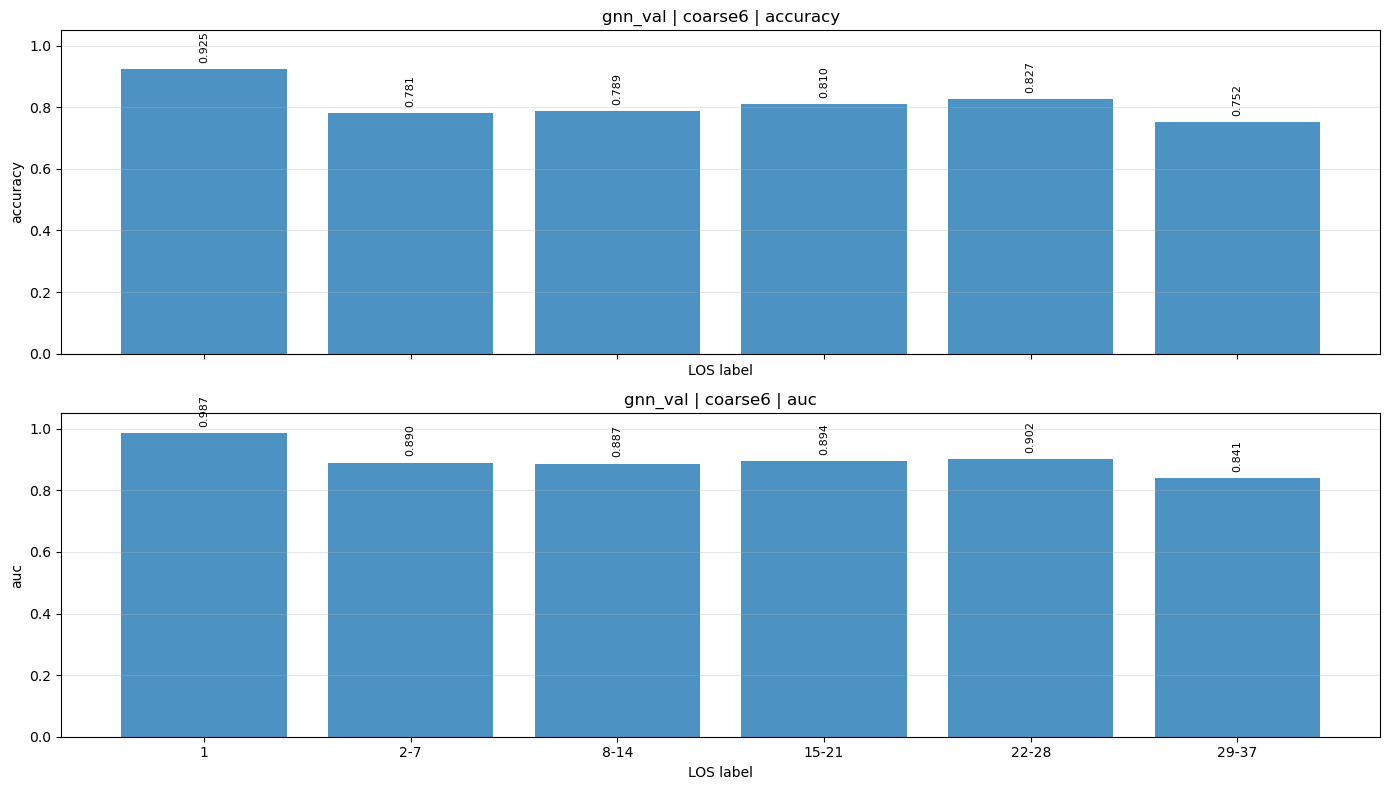

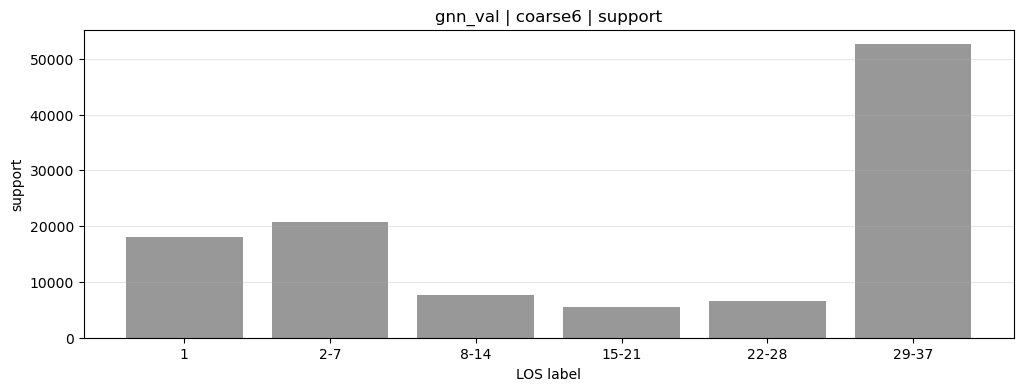

In [20]:
# Histogram + LOS-group metric view in one flow
def show_los_hist_and_group_metrics(run_name: str, *, fold: int = 0, split: str = 'gnn_val', los_space: str = 'coarse6', min_support: int = 0):
    print(f'run_name={run_name}')
    print('[1] prediction histogram: true vs pred los')
    show_comparing_hist(run_name, 'los')

    print('[2] LOS-group metrics table preview')
    group_metrics_df = load_forecasted_gnn_group_metrics(run_name, fold=fold)
    preview_df = _ordered_group_df(group_metrics_df, split=split, los_space=los_space)
    preview_df = preview_df[preview_df['support'] >= min_support].copy()
    display(preview_df[['los_label_name', 'support', 'accuracy', 'auc', 'precision', 'recall', 'f1']])

    print('[3] LOS-group accuracy / auc')
    plot_los_group_acc_auc(group_metrics_df, split=split, los_space=los_space, min_support=min_support);

    print('[4] LOS-group support')
    plot_los_group_support(group_metrics_df, split=split, los_space=los_space);

    return group_metrics_df

# Example usage
show_los_hist_and_group_metrics(
    run_name,
    fold=0,
    split='gnn_val',
    los_space='coarse6',
    min_support=0,
)


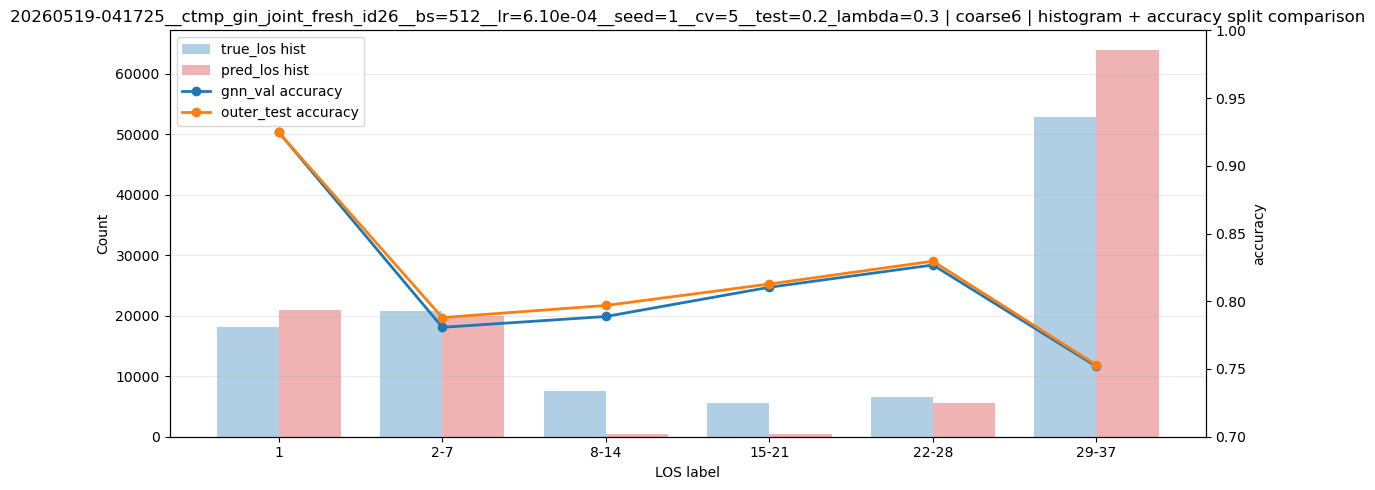

In [21]:
# Overlay: LOS true/pred histogram + split-comparison line in one figure
def _prepare_los_histogram_counts(run_name: str, *, los_space: str = 'coarse6') -> pd.DataFrame:
    pred_df = _get_predictions_df(run_name)
    pred_df, pred_los_type, true_los_type = _make_los_type_identical(pred_df)

    work_df = pred_df[['true_los', 'pred_los']].copy()
    if los_space == 'coarse6':
        if pred_los_type != 'coarse':
            work_df['true_los'] = map_los_array_to_coarse_bins(work_df['true_los'])
            work_df['pred_los'] = map_los_array_to_coarse_bins(work_df['pred_los'])
        classes = list(range(6))
        labels = COARSE6_LABEL_ORDER
    elif los_space == 'raw37':
        if pred_los_type == 'coarse':
            raise ValueError('raw37 overlay requires raw37 predictions, but this run stores coarse pred_los.')
        classes = list(range(1, 38))
        labels = [str(v) for v in classes]
    else:
        raise ValueError(f'Unsupported los_space: {los_space}')

    true_counts = work_df['true_los'].astype(int).value_counts().reindex(classes, fill_value=0)
    pred_counts = work_df['pred_los'].astype(int).value_counts().reindex(classes, fill_value=0)
    return pd.DataFrame({
        'los_label_name': labels,
        'true_count': true_counts.values,
        'pred_count': pred_counts.values,
    })

def plot_los_hist_with_split_comparison(run_name: str, *, fold: int = 0, los_space: str = 'coarse6', metric: str = 'accuracy', min_support: int = 0, normalize_hist: bool = False):
    hist_df = _prepare_los_histogram_counts(run_name, los_space=los_space)
    metric_df = load_forecasted_gnn_group_metrics(run_name, fold=fold)
    metric_df = metric_df[metric_df['los_space'] == los_space].copy()
    metric_df = metric_df[metric_df['support'] >= min_support].copy()

    if los_space == 'coarse6':
        order = COARSE6_LABEL_ORDER
    else:
        order = [str(v) for v in range(1, 38)]

    hist_df['los_label_name'] = pd.Categorical(hist_df['los_label_name'], categories=order, ordered=True)
    hist_df = hist_df.sort_values('los_label_name').reset_index(drop=True)

    pivot = metric_df.pivot(index='split', columns='los_label_name', values=metric).reindex(columns=order)

    x = np.arange(len(order))
    fig, ax1 = plt.subplots(figsize=(max(12, len(order) * 0.5), 5))

    true_vals = hist_df['true_count'].astype(float).to_numpy()
    pred_vals = hist_df['pred_count'].astype(float).to_numpy()
    if normalize_hist:
        if true_vals.sum() > 0:
            true_vals = true_vals / true_vals.sum()
        if pred_vals.sum() > 0:
            pred_vals = pred_vals / pred_vals.sum()

    width = 0.38
    ax1.bar(x - width / 2, true_vals, width=width, alpha=0.35, color='tab:blue', label='true_los hist')
    ax1.bar(x + width / 2, pred_vals, width=width, alpha=0.35, color='tab:red', label='pred_los hist')
    ax1.set_xlabel('LOS label')
    ax1.set_ylabel('Proportion' if normalize_hist else 'Count')
    ax1.set_xticks(x)
    ax1.set_xticklabels(order, rotation=45 if los_space == 'raw37' else 0)
    ax1.grid(axis='y', alpha=0.25)

    ax2 = ax1.twinx()
    for split_name, row in pivot.iterrows():
        y = pd.to_numeric(row.reindex(order), errors='coerce').to_numpy(dtype=float)
        ax2.plot(x, y, marker='o', linewidth=2, label=f'{split_name} {metric}')
    ax2.set_ylabel(metric)
    if metric in {'accuracy', 'precision', 'recall', 'f1', 'auc'}:
        ax2.set_ylim(0.7, 1.0)

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')
    ax1.set_title(f'{run_name} | {los_space} | histogram + {metric} split comparison')
    fig.tight_layout()
    return fig, (ax1, ax2)

# Example usage: same plot with histogram bars and split-comparison lines
plot_los_hist_with_split_comparison(
    run_name,
    fold=0,
    los_space='coarse6',
    metric='accuracy',
    min_support=0,
    normalize_hist=False,
);


20260519-041725__ctmp_gin_joint_fresh_id26__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2_lambda=0.3 | joint val_predictions | coarse6 LOS confusion (true x pred, row pct)
metadata: {'pred_los_type': 'coarse', 'true_los_type': 'raw37', 'n_rows': 111531}


,bin,label
0,0,1
1,1,2-7
2,2,8-14
3,3,15-21
4,4,22-28
5,5,29-37


[1] true x pred coarse6 confusion counts


pred_los,0:1,1:2-7,2:8-14,3:15-21,4:22-28,5:29-37
true_los,,,,,,
0:1,13038,2176,30,20,214,2664
1:2-7,1767,13842,116,96,915,4020
2:8-14,871,2108,192,104,853,3428
3:15-21,659,581,89,133,907,3233
4:22-28,623,425,71,103,1850,3532
5:29-37,4055,874,34,21,779,47108


[2] true x pred coarse6 row-normalized percent


...

pred_los,0:1,1:2-7,2:8-14,3:15-21,4:22-28,5:29-37
true_los,,,,,,
0:1,77.19,10.25,1.26,0.92,2.02,8.37
1:2-7,12.70,63.16,3.98,2.55,3.31,14.30
2:8-14,13.86,25.51,11.15,6.69,7.10,35.69
3:15-21,13.45,8.27,10.22,11.35,10.44,46.27
4:22-28,10.31,4.92,8.58,10.85,23.82,41.51
5:29-37,8.70,1.83,1.00,1.04,3.32,84.11


[3] true bin 2/3 routing to pred bin 1, 4, 5


,true_bin,support,correct,accuracy_pct,top_pred_bin,top_pred_count,top_pred_pct,to_bin_1_count,to_bin_1_pct,to_bin_4_count,to_bin_4_pct,to_bin_5_count,to_bin_5_pct
0,2:8-14,14188,1582,11.15,5:29-37,5063,35.69,3620,25.51,1007,7.10,5063,35.69
1,3:15-21,10524,1194,11.35,5:29-37,4869,46.27,870,8.27,1099,10.44,4869,46.27


[4] pred bin 1 incoming true-bin breakdown


,true_bin,count_to_pred_bin_1,share_of_pred_bin_1_pct
0,0:1,3463,9.91
1,1:2-7,24550,70.28
2,2:8-14,3620,10.36
3,3:15-21,870,2.49
4,4:22-28,601,1.72
5,5:29-37,1826,5.23


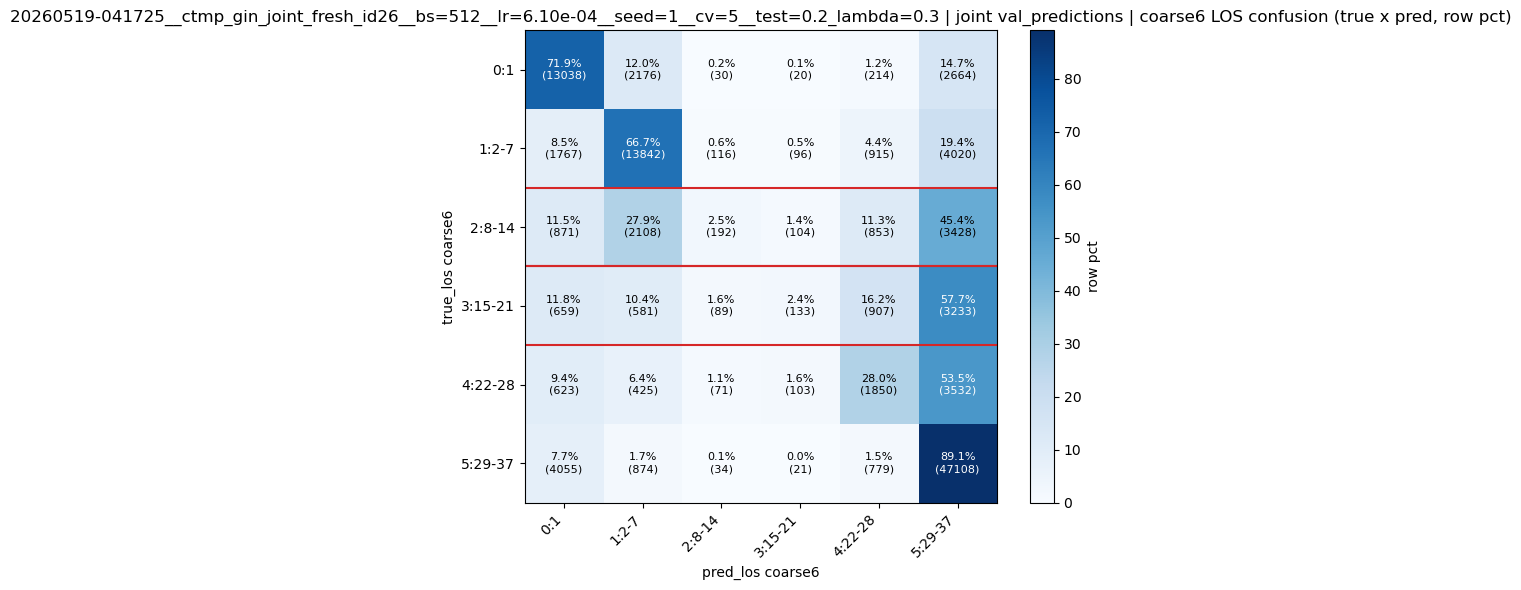

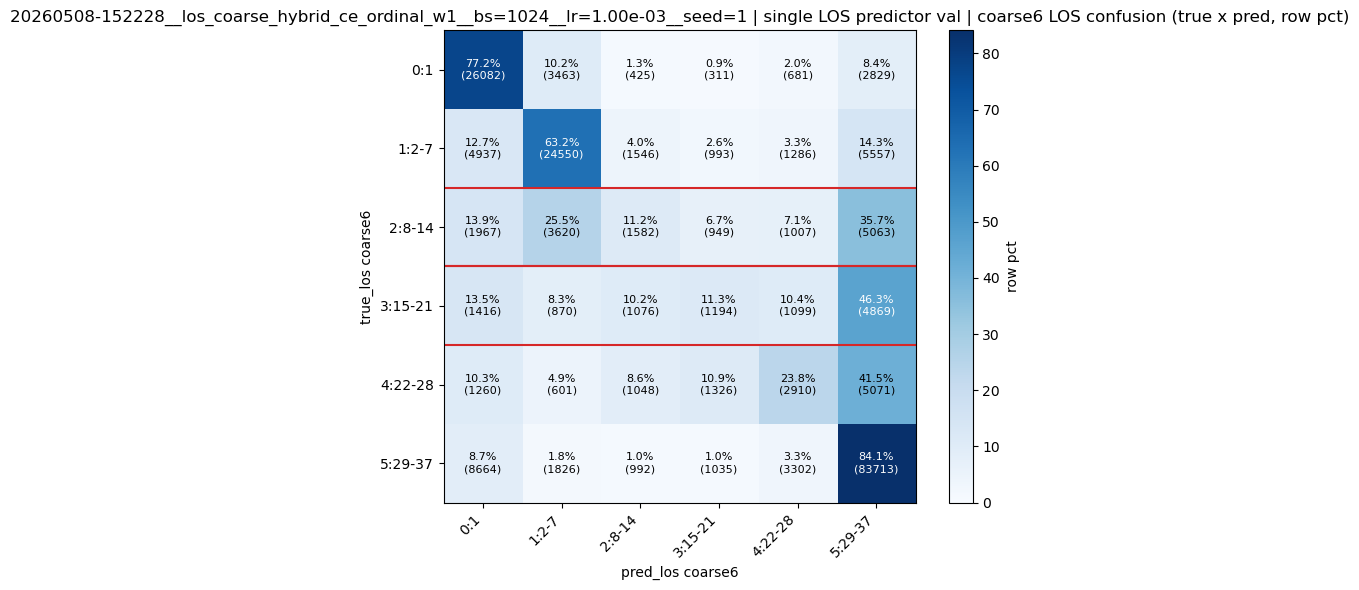

In [22]:
# Coarse6 LOS confusion matrix (true x pred) and bin 2/3 routing check
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

COARSE6_BIN_LABELS = [f'{idx}:{label}' for idx, label in enumerate(COARSE6_LABEL_ORDER)]

def _get_coarse6_los_pairs(run_name: str):
    pred_df = _get_predictions_df(run_name)
    pred_df, pred_los_type, true_los_type = _make_los_type_identical(pred_df)

    work_df = pred_df[['true_los', 'pred_los']].copy()
    if pred_los_type == 'raw37':
        work_df['true_los'] = map_los_array_to_coarse_bins(work_df['true_los'])
        work_df['pred_los'] = map_los_array_to_coarse_bins(work_df['pred_los'])
    elif pred_los_type != 'coarse':
        raise ValueError(f'Unsupported pred_los_type: {pred_los_type}')

    work_df['true_los'] = work_df['true_los'].astype(int)
    work_df['pred_los'] = work_df['pred_los'].astype(int)
    invalid_mask = ~work_df['true_los'].isin(range(6)) | ~work_df['pred_los'].isin(range(6))
    if invalid_mask.any():
        invalid_values = work_df.loc[invalid_mask, ['true_los', 'pred_los']].drop_duplicates()
        raise ValueError(f'Expected coarse6 labels in 0..5, got:\n{invalid_values}')

    return work_df, pred_los_type, true_los_type

def _focus_true_bin_flow_summary(cm_counts: pd.DataFrame, row_pct: pd.DataFrame, *, focus_true_bins=(2, 3), compare_pred_bins=(1, 4, 5)) -> pd.DataFrame:
    rows = []
    for true_bin in focus_true_bins:
        counts_row = cm_counts.iloc[true_bin]
        pct_row = row_pct.iloc[true_bin]
        support = int(counts_row.sum())
        top_pred_bin = int(np.argmax(counts_row.to_numpy())) if support else None

        row = {
            'true_bin': COARSE6_BIN_LABELS[true_bin],
            'support': support,
            'correct': int(counts_row.iloc[true_bin]),
            'accuracy_pct': float(pct_row.iloc[true_bin] * 100) if support else np.nan,
            'top_pred_bin': COARSE6_BIN_LABELS[top_pred_bin] if top_pred_bin is not None else None,
            'top_pred_count': int(counts_row.iloc[top_pred_bin]) if top_pred_bin is not None else 0,
            'top_pred_pct': float(pct_row.iloc[top_pred_bin] * 100) if support and top_pred_bin is not None else np.nan,
        }
        for pred_bin in compare_pred_bins:
            row[f'to_bin_{pred_bin}_count'] = int(counts_row.iloc[pred_bin])
            row[f'to_bin_{pred_bin}_pct'] = float(pct_row.iloc[pred_bin] * 100) if support else np.nan
        rows.append(row)

    return pd.DataFrame(rows)

def _incoming_pred_bin_summary(cm_counts: pd.DataFrame, *, pred_bin: int = 1) -> pd.DataFrame:
    pred_counts = cm_counts.iloc[:, pred_bin]
    total = int(pred_counts.sum())
    share = pred_counts / total if total else pred_counts * np.nan
    return pd.DataFrame({
        'true_bin': COARSE6_BIN_LABELS,
        f'count_to_pred_bin_{pred_bin}': pred_counts.to_numpy(dtype=int),
        f'share_of_pred_bin_{pred_bin}_pct': (share * 100).to_numpy(dtype=float),
    })

def build_coarse6_los_confusion(run_name: str):
    work_df, pred_los_type, true_los_type = _get_coarse6_los_pairs(run_name)
    classes = list(range(6))

    cm_counts = pd.crosstab(work_df['true_los'], work_df['pred_los'])
    cm_counts = cm_counts.reindex(index=classes, columns=classes, fill_value=0)
    cm_counts.index = pd.Index(COARSE6_BIN_LABELS, name='true_los')
    cm_counts.columns = pd.Index(COARSE6_BIN_LABELS, name='pred_los')
    row_pct = cm_counts.div(cm_counts.sum(axis=1).replace(0, np.nan), axis=0)

    focus_summary = _focus_true_bin_flow_summary(cm_counts, row_pct)
    pred_bin1_incoming = _incoming_pred_bin_summary(cm_counts, pred_bin=1)
    metadata = {'pred_los_type': pred_los_type, 'true_los_type': true_los_type, 'n_rows': len(work_df)}
    return cm_counts, row_pct, focus_summary, pred_bin1_incoming, metadata

def _normalize_run_name(run_name: str) -> str:
    return str(run_name).strip().lstrip('@')

def _format_coarse6_confusion_counts(cm_df: pd.DataFrame) -> pd.DataFrame:
    classes = list(range(6))
    if 'true_class' in cm_df.columns:
        cm_df = cm_df.set_index('true_class')
    cm_df.index = cm_df.index.astype(int)
    cm_df.columns = cm_df.columns.astype(int)
    cm_counts = cm_df.reindex(index=classes, columns=classes, fill_value=0).astype(int)
    cm_counts.index = pd.Index(COARSE6_BIN_LABELS, name='true_los')
    cm_counts.columns = pd.Index(COARSE6_BIN_LABELS, name='pred_los')
    return cm_counts

def _resolve_single_los_confusion_path(run_name: str, *, split: str = 'val', suffix: str = 'coarse') -> Path:
    run_dir = _resolve_run_dir(_normalize_run_name(run_name))
    exact_path = run_dir / f'{split}_confusion_matrix_{suffix}.csv'
    if exact_path.exists():
        return exact_path

    candidates = sorted(run_dir.glob(f'{split}_confusion_matrix_*.csv'))
    if len(candidates) == 1:
        return candidates[0]
    if candidates:
        candidate_names = [path.name for path in candidates]
        raise ValueError(f'Multiple {split} confusion matrices found. Set suffix explicitly. candidates={candidate_names}')
    raise FileNotFoundError(f'No {split}_confusion_matrix_*.csv found under {run_dir}')

def build_single_los_predictor_coarse6_confusion(run_name: str, *, split: str = 'val', suffix: str = 'coarse'):
    cm_path = _resolve_single_los_confusion_path(run_name, split=split, suffix=suffix)
    cm_counts = _format_coarse6_confusion_counts(pd.read_csv(cm_path))
    row_pct = cm_counts.div(cm_counts.sum(axis=1).replace(0, np.nan), axis=0)
    focus_summary = _focus_true_bin_flow_summary(cm_counts, row_pct)
    pred_bin1_incoming = _incoming_pred_bin_summary(cm_counts, pred_bin=1)
    metadata = {
        'run_name': _normalize_run_name(run_name),
        'split': split,
        'suffix': suffix,
        'confusion_path': str(cm_path),
        'n_rows': int(cm_counts.to_numpy().sum()),
    }
    return cm_counts, row_pct, focus_summary, pred_bin1_incoming, metadata

def plot_coarse6_los_confusion_heatmap(cm_counts: pd.DataFrame, row_pct: pd.DataFrame, *, title: str):
    data = (row_pct * 100).to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(9, 6))
    vmax = np.nanmax(data) if np.isfinite(data).any() else 1.0
    im = ax.imshow(data, cmap='Blues', vmin=0.0, vmax=vmax)

    ax.set_xticks(np.arange(len(COARSE6_BIN_LABELS)))
    ax.set_xticklabels(COARSE6_BIN_LABELS, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(COARSE6_BIN_LABELS)))
    ax.set_yticklabels(COARSE6_BIN_LABELS)
    ax.set_xlabel('pred_los coarse6')
    ax.set_ylabel('true_los coarse6')
    ax.set_title(title)

    threshold = vmax * 0.55
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            pct = data[i, j]
            count = int(cm_counts.iloc[i, j])
            color = 'white' if np.isfinite(pct) and pct > threshold else 'black'
            label = 'NA' if not np.isfinite(pct) else f'{pct:.1f}%\n({count})'
            ax.text(j, i, label, ha='center', va='center', color=color, fontsize=8)

    for true_bin in (2, 3):
        ax.axhline(true_bin - 0.5, color='tab:red', linewidth=1.5)
        ax.axhline(true_bin + 0.5, color='tab:red', linewidth=1.5)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='row pct')
    fig.tight_layout()
    return fig, ax

def show_coarse6_los_confusion(cm_counts: pd.DataFrame, row_pct: pd.DataFrame, focus_summary: pd.DataFrame, pred_bin1_incoming: pd.DataFrame, metadata: dict, *, title: str):
    print(title)
    print('metadata:', metadata)
    display(pd.DataFrame({'bin': list(range(6)), 'label': COARSE6_LABEL_ORDER}))

    print('[1] true x pred coarse6 confusion counts')
    display(cm_counts)

    print('[2] true x pred coarse6 row-normalized percent')
    display((row_pct * 100).round(2))

    print('[3] true bin 2/3 routing to pred bin 1, 4, 5')
    display(focus_summary.round(2))

    print('[4] pred bin 1 incoming true-bin breakdown')
    display(pred_bin1_incoming.round(2))

    plot_coarse6_los_confusion_heatmap(cm_counts, row_pct, title=title);

coarse6_los_confusion_counts, coarse6_los_confusion_row_pct, bin23_flow_summary, pred_bin1_incoming_summary, coarse6_confusion_metadata = build_coarse6_los_confusion(run_name)

show_coarse6_los_confusion(
    coarse6_los_confusion_counts,
    coarse6_los_confusion_row_pct,
    bin23_flow_summary,
    pred_bin1_incoming_summary,
    coarse6_confusion_metadata,
    title=f'{run_name} | joint val_predictions | coarse6 LOS confusion (true x pred, row pct)',
)

# Single LOS predictor training artifacts: reads precomputed val/test_confusion_matrix_*.csv.
single_los_run_name = '@20260508-152228__los_coarse_hybrid_ce_ordinal_w1__bs=1024__lr=1.00e-03__seed=1'
single_los_split = 'val'
single_los_cm_counts, single_los_row_pct, single_los_bin23_flow_summary, single_los_pred_bin1_incoming_summary, single_los_metadata = build_single_los_predictor_coarse6_confusion(
    single_los_run_name,
    split=single_los_split,
    suffix='coarse',
)
show_coarse6_los_confusion(
    single_los_cm_counts,
    single_los_row_pct,
    single_los_bin23_flow_summary,
    single_los_pred_bin1_incoming_summary,
    single_los_metadata,
    title=f'{_normalize_run_name(single_los_run_name)} | single LOS predictor {single_los_split} | coarse6 LOS confusion (true x pred, row pct)',
)



run_name=20260519-030905__ctmp_gin_joint_fresh_id22__bs=512__lr=6.10e-04__seed=1__cv=5__test=0.2_lambda=0.3
metadata: {'pred_los_type': 'coarse', 'true_los_type': 'raw37', 'n_rows': 111531}


,bin,label
0,0,1
1,1,2-7
2,2,8-14
3,3,15-21
4,4,22-28
5,5,29-37


[1] true x pred coarse6 confusion counts


pred_los,0:1,1:2-7,2:8-14,3:15-21,4:22-28,5:29-37
true_los,,,,,,
0:1,13481,2204,30,2,161,2264
1:2-7,1881,14109,157,9,759,3841
2:8-14,921,2297,281,8,754,3295
3:15-21,695,765,197,11,841,3093
4:22-28,653,602,116,2,1877,3354
5:29-37,4362,899,59,4,751,46796


[2] true x pred coarse6 row-normalized percent


...

pred_los,0:1,1:2-7,2:8-14,3:15-21,4:22-28,5:29-37
true_los,,,,,,
0:1,71.66,12.00,0.44,0.09,1.07,14.74
1:2-7,7.80,67.41,2.11,0.23,4.01,18.44
2:8-14,11.10,26.54,7.64,0.40,10.31,44.02
3:15-21,11.09,9.85,7.00,2.95,14.91,54.21
4:22-28,8.89,5.95,3.85,0.18,31.09,50.05
5:29-37,7.18,1.60,0.20,0.22,1.60,89.20


[3] true bin 2/3 routing to pred bin 1, 4, 5


,true_bin,support,correct,accuracy_pct,top_pred_bin,top_pred_count,top_pred_pct,to_bin_1_count,to_bin_1_pct,to_bin_4_count,to_bin_4_pct,to_bin_5_count,to_bin_5_pct
0,2:8-14,7556,577,7.64,5:29-37,3326,44.02,2005,26.54,779,10.31,3326,44.02
1,3:15-21,5602,165,2.95,5:29-37,3037,54.21,552,9.85,835,14.91,3037,54.21


[4] pred bin 1 incoming true-bin breakdown


,true_bin,count_to_pred_bin_1,share_of_pred_bin_1_pct
0,0:1,2177,10.91
1,1:2-7,13992,70.09
2,2:8-14,2005,10.04
3,3:15-21,552,2.77
4,4:22-28,393,1.97
5,5:29-37,844,4.23


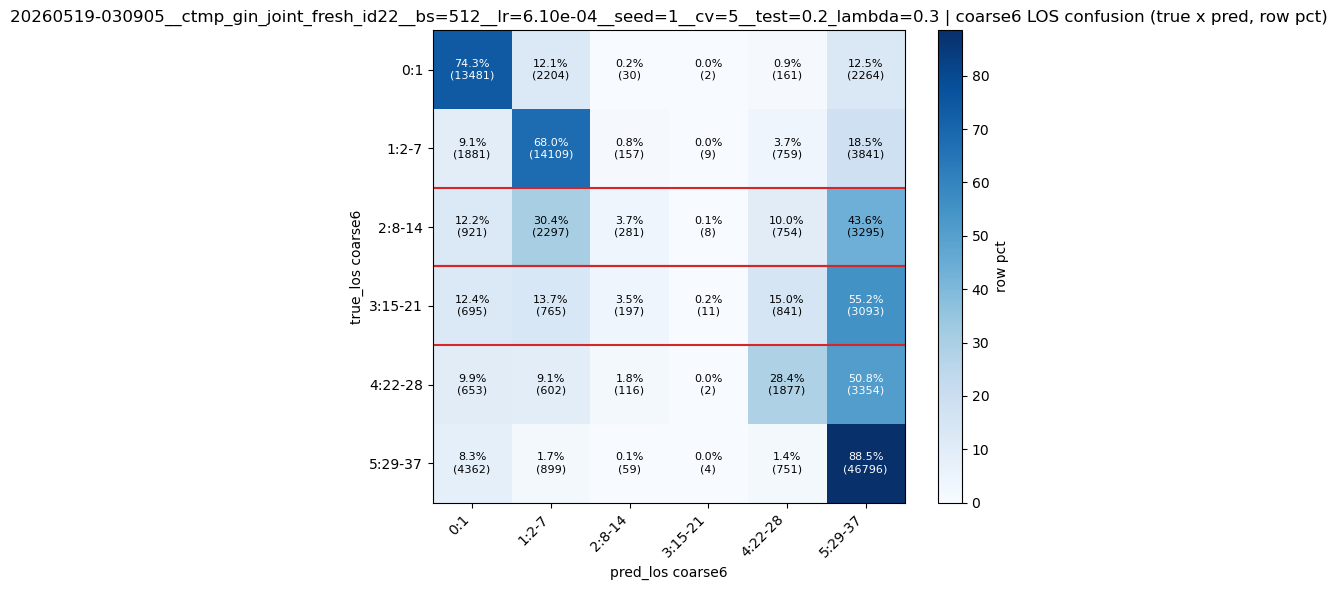

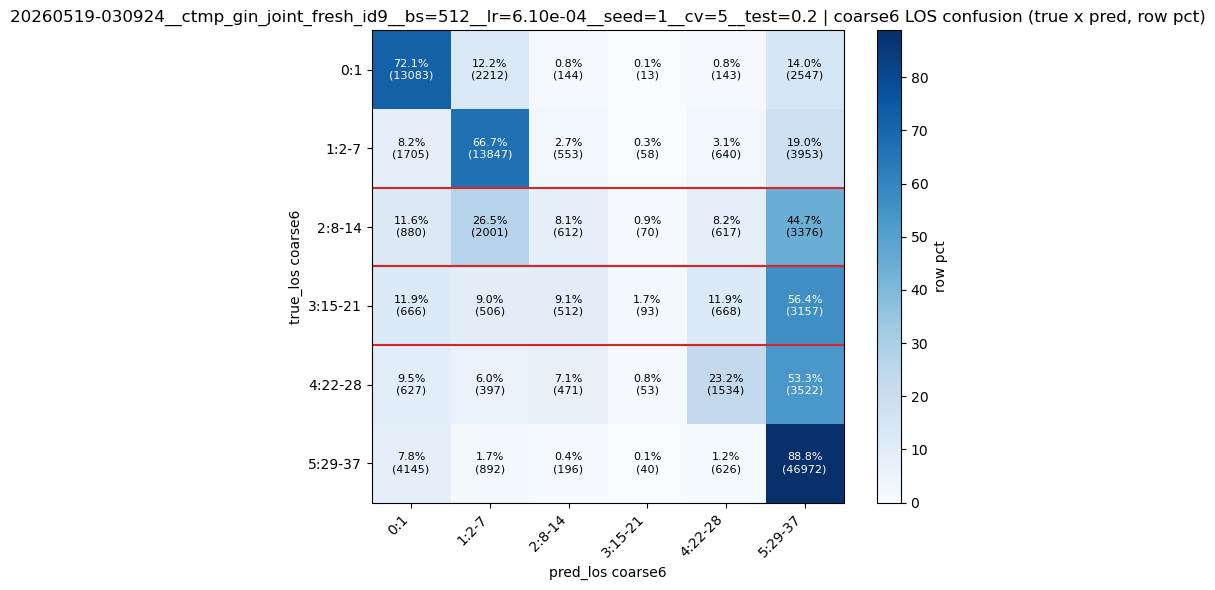

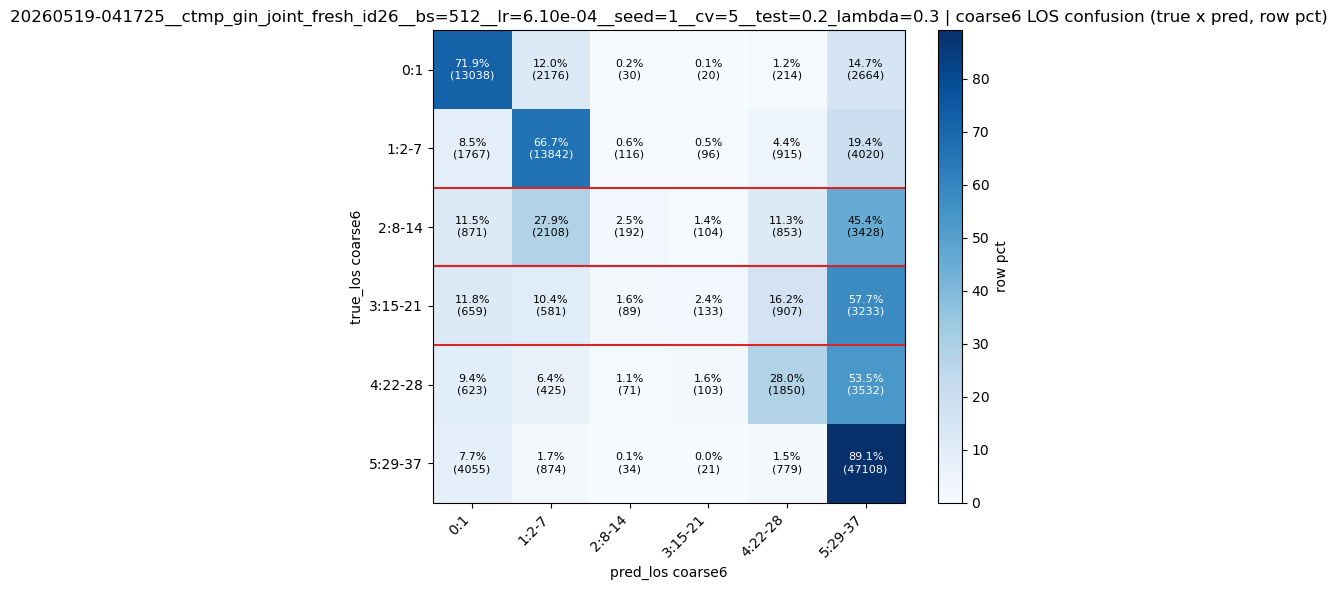

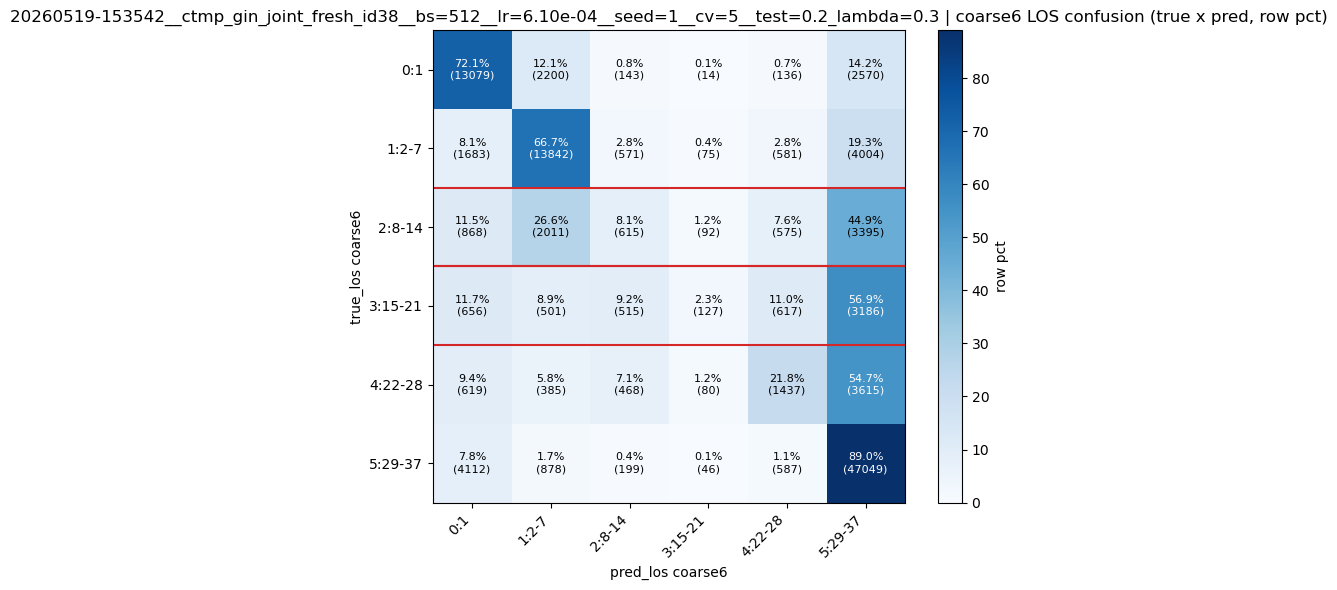

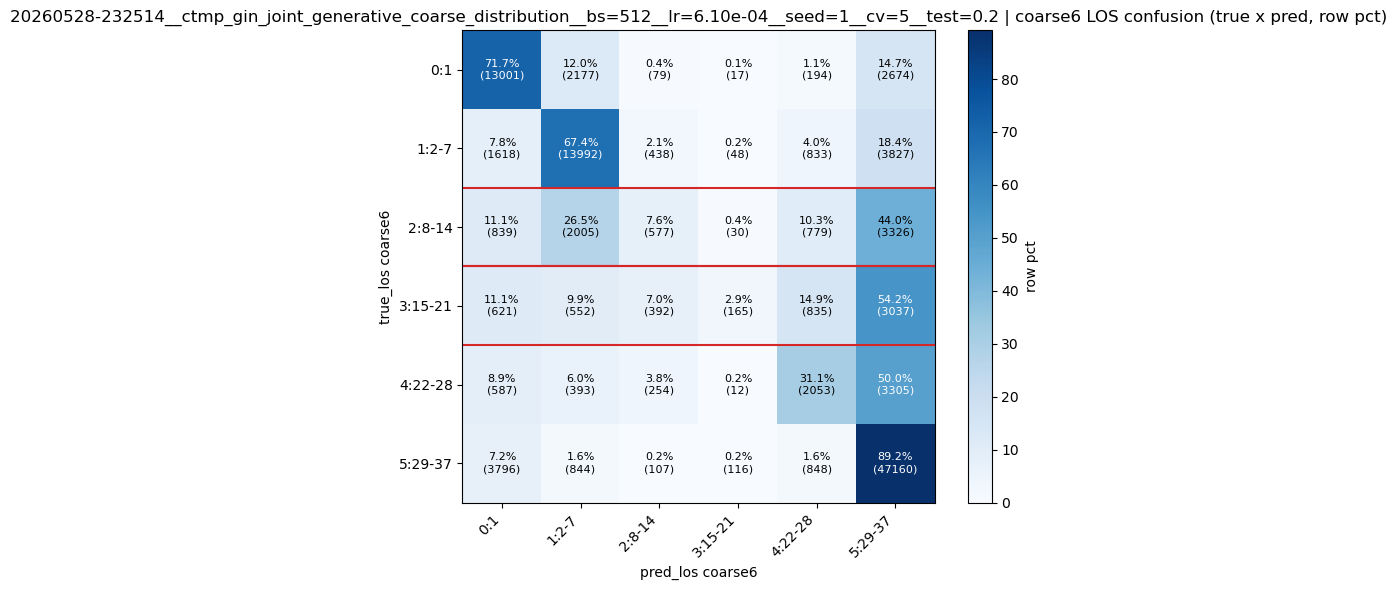

In [23]:
for run_name in check_list:
    coarse6_los_confusion_counts, coarse6_los_confusion_row_pct, bin23_flow_summary, pred_bin1_incoming_summary, coarse6_confusion_metadata = build_coarse6_los_confusion(run_name)

    print(f'run_name={run_name}')
    print('metadata:', coarse6_confusion_metadata)
    display(pd.DataFrame({'bin': list(range(6)), 'label': COARSE6_LABEL_ORDER}))

    print('[1] true x pred coarse6 confusion counts')
    display(coarse6_los_confusion_counts)

    print('[2] true x pred coarse6 row-normalized percent')
    display((coarse6_los_confusion_row_pct * 100).round(2))

    print('[3] true bin 2/3 routing to pred bin 1, 4, 5')
    display(bin23_flow_summary.round(2))

    print('[4] pred bin 1 incoming true-bin breakdown')
    display(pred_bin1_incoming_summary.round(2))

    plot_coarse6_los_confusion_heatmap(
        coarse6_los_confusion_counts,
        coarse6_los_confusion_row_pct,
        title=f'{run_name} | coarse6 LOS confusion (true x pred, row pct)',
    )


희소 LOS 클래스에서보다 29-37에서 더 많은 성능 degradation이 있다. 희소 클래스를 제대로 못 맞추었기 때문에 성능이 안 좋은 것이라는 가설보다 더 중요한 것은
장기 입원 환자들에 대한 예측력의 감소라고 볼 수도 있다.

또는 희소 클래스를 맞추는 대신 이들에 대한 예측을 모두 장기 입원 케이스인 것으로 모델이 찍게 되고,
그렇게 찍었기 때문에 희소 클래스쪽도 망가지고, 장기 입원 클래스쪽도 망가지는 것 아닐까?

그렇다면 2-7 클래스에서의 성능 저하를 설명하지는 못한다. 

In [24]:
import numpy as np, pandas as pd

def _js(p, q, eps=1e-12):
    p = np.asarray(p, float) + eps; q = np.asarray(q, float) + eps
    p /= p.sum(); q /= q.sum(); m = 0.5*(p+q)
    kl = lambda a,b: np.sum(a*np.log2(a/b))
    return 0.5*kl(p,m) + 0.5*kl(q,m)

def _cramers_v(t):
    t = np.asarray(t, float); n = t.sum()
    if n == 0: return np.nan
    exp = t.sum(1,keepdims=True) @ t.sum(0,keepdims=True) / n
    exp = np.where(exp==0, 1e-12, exp)
    chi2 = ((t-exp)**2/exp).sum()
    k = min(t.shape)
    return 0.0 if k<=1 else np.sqrt(chi2/(n*(k-1)))

def _table(d, ell, classes, n_bins=6):
    idx = {c:i for i,c in enumerate(classes)}
    t = np.zeros((len(classes), n_bins))
    for di, li in zip(d, ell):
        if 0 <= li < n_bins: t[idx[di], li] += 1
    return t

def decompose_head_drift(df, head, n_bins=6):
    td = df[f'true_{head}'].astype(int).to_numpy()
    pd_ = df[f'pred_{head}'].astype(int).to_numpy()
    tl = df['true_los'].astype(int).to_numpy()   # _make_los_type_identical 후 coarse 0..5
    pl = df['pred_los'].astype(int).to_numpy()
    cls = sorted(set(td) | set(pd_))
    T_or, T_mid, T_full = _table(td,tl,cls,n_bins), _table(td,pl,cls,n_bins), _table(pd_,pl,cls,n_bins)

    def avg_js(A, B, W):
        w = W.sum(0)
        j = np.array([_js(A[:,b], B[:,b]) if A[:,b].sum()>0 and B[:,b].sum()>0 else 0.0
                      for b in range(n_bins)])
        return np.average(j, weights=w) if w.sum()>0 else np.nan

    return dict(head=head, acc=(td==pd_).mean(),
                V_oracle=_cramers_v(T_or),
                dV_LOS=_cramers_v(T_mid)-_cramers_v(T_or),     # LOS 귀속
                dV_D=_cramers_v(T_full)-_cramers_v(T_mid),     # D 귀속
                js_LOS=avg_js(T_or, T_mid, T_or),
                js_D=avg_js(T_mid, T_full, T_full))

# 사용
df = _get_predictions_df(run_name)
df, *_ = _make_los_type_identical(df)   # true/pred los를 같은 coarse 공간으로
heads = sorted({c[5:] for c in df.columns
                if c.startswith('true_') and c[5:]!='los' and f'pred_{c[5:]}' in df.columns})
report = pd.DataFrame([decompose_head_drift(df, h) for h in heads]).sort_values('dV_D', ascending=False)
report

,head,acc,V_oracle,dV_LOS,dV_D,js_LOS,js_D
6,FREQ_ATND_SELF_HELP_D,0.757368,0.107388,0.045042,0.052753,0.018098,0.017776
9,SUB1_D,0.885476,0.101559,0.048541,0.041161,0.016912,0.006327
3,FREQ1_D,0.805830,0.173997,0.019668,0.024770,0.011432,0.005769
1,DETNLF_D,0.892954,0.054228,0.034406,0.017931,0.005489,0.003925
5,FREQ3_D,0.954228,0.058683,0.004524,0.016812,0.002224,0.001258
2,EMPLOY_D,0.788471,0.110294,0.010675,0.014326,0.009420,0.002654
8,SERVICES_D,0.983368,0.328705,0.157462,0.010858,0.061358,0.001224
10,SUB2_D,0.905730,0.062140,0.043506,0.009354,0.015076,0.001059
4,FREQ2_D,0.952327,0.047611,0.022014,0.008175,0.001229,0.000439
0,ARRESTS_D,0.877451,0.050295,0.038410,0.003076,0.011452,0.005990


LOS bin에서 장기 입원 환자들에 대한 세부 분류

In [25]:
import numpy as np
import pandas as pd
los = df_b["LOS"]

bound = [-np.inf, 1, 7, 14, 21, 28, 31, 33, 35, np.inf]

los_cut = pd.cut(los, bound)
los_cut.value_counts(sort=False)

LOS
(-inf, 1.0]     226408
(1.0, 7.0]      259111
(7.0, 14.0]      95228
(14.0, 21.0]     69612
(21.0, 28.0]     82004
(28.0, 31.0]    115364
(31.0, 33.0]    174652
(33.0, 35.0]    178515
(35.0, inf]     193244
Name: count, dtype: int64

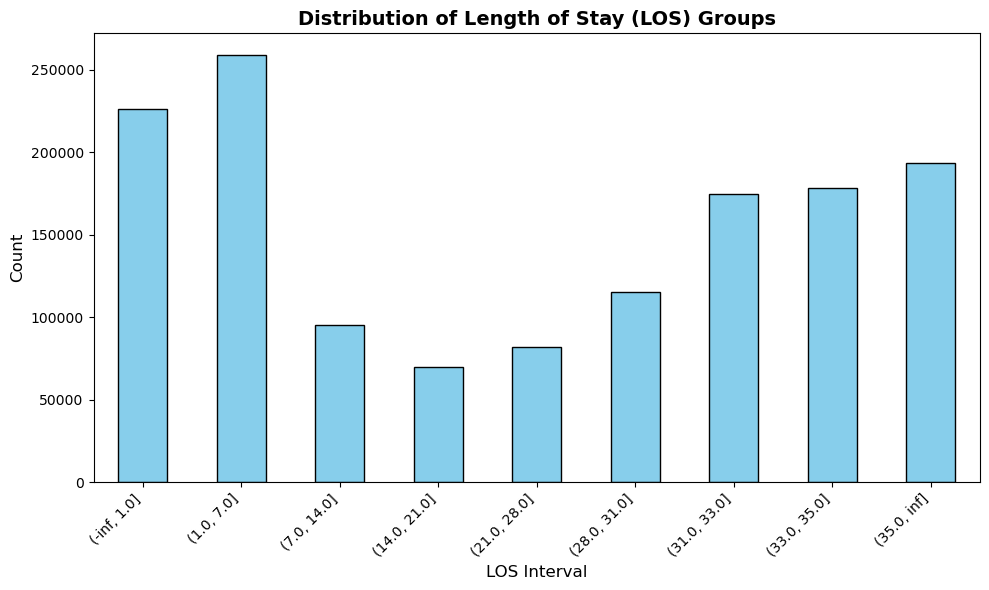

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 안전하게 범위를 확장 (0 이하, 28 초과 데이터까지 수용)
# 만약 미만~이상으로 나누고 싶다면 right=False 옵션을 추가하세요.
bound = [-np.inf, 1, 7, 14, 21, 28, 31, 33, 35, np.inf]
df_b["los_cut"] = pd.cut(df_b["LOS"], bound)

# 2. 구간별 데이터 개수 계산 및 정렬
# .sort_index()를 해주어야 (0, 1], (1, 7] 순서대로 예쁘게 정렬됩니다.
counts = df_b["los_cut"].value_counts().sort_index()

# 3. matplotlib을 이용한 시각화
fig, ax = plt.subplots(figsize=(10, 6))
counts.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')

# 그래프 스타일 설정
ax.set_title("Distribution of Length of Stay (LOS) Groups", fontsize=14, fontweight='bold')
ax.set_xlabel("LOS Interval", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

# X축 레이블이 겹치지 않도록 회전 및 정렬
ax.set_xticklabels(counts.index.astype(str), rotation=45, ha='right')

# 그래프 여백 조정 후 출력/저장
plt.tight_layout()
plt.savefig("los_distribution.png")  # 파일로 저장할 경우
plt.show()

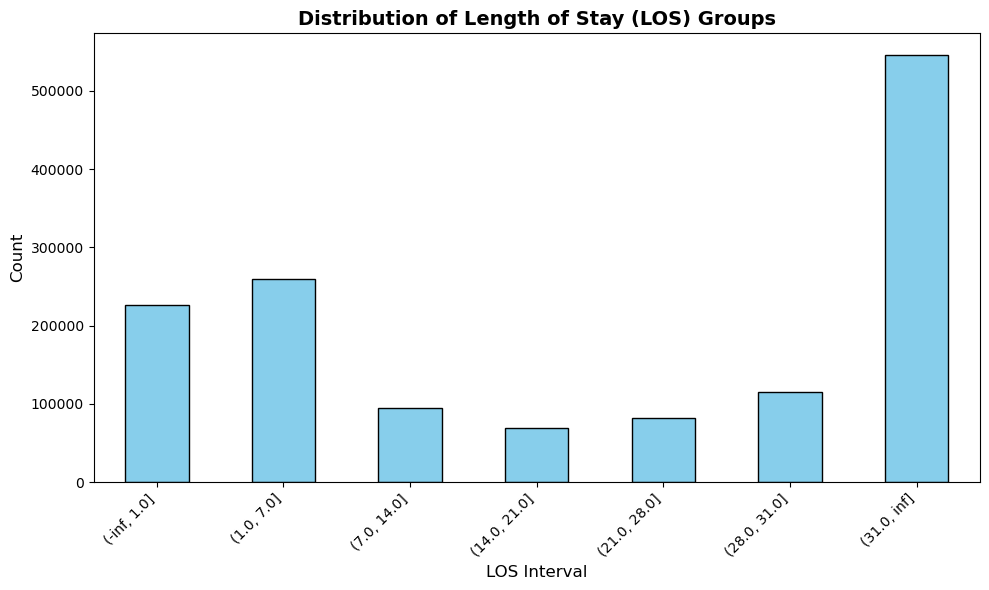

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 안전하게 범위를 확장 (0 이하, 28 초과 데이터까지 수용)
# 만약 미만~이상으로 나누고 싶다면 right=False 옵션을 추가하세요.
bound = [-np.inf, 1, 7, 14, 21, 28, 31, np.inf]
df_b["los_cut"] = pd.cut(df_b["LOS"], bound)

# 2. 구간별 데이터 개수 계산 및 정렬
# .sort_index()를 해주어야 (0, 1], (1, 7] 순서대로 예쁘게 정렬됩니다.
counts = df_b["los_cut"].value_counts().sort_index()

# 3. matplotlib을 이용한 시각화
fig, ax = plt.subplots(figsize=(10, 6))
counts.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')

# 그래프 스타일 설정
ax.set_title("Distribution of Length of Stay (LOS) Groups", fontsize=14, fontweight='bold')
ax.set_xlabel("LOS Interval", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

# X축 레이블이 겹치지 않도록 회전 및 정렬
ax.set_xticklabels(counts.index.astype(str), rotation=45, ha='right')

# 그래프 여백 조정 후 출력/저장
plt.tight_layout()
plt.savefig("los_distribution.png")  # 파일로 저장할 경우
plt.show()

pred_los_bin,1,2-7,8-14,15-21,22-28,29-31,32-33,34-35,36-37
true_los_bin,,,,,,,,,
1,30175,4567,170,114,336,211,706,1197,1014
2-7,4340,30103,965,427,1589,839,2389,2163,1234
8-14,2399,4517,1351,423,1478,660,2179,1947,1235
15-21,1706,1358,749,691,1565,651,1860,1886,1368
22-28,1526,1102,627,342,4232,1203,1907,1806,1195
29-31,2712,896,261,98,1625,2398,4370,4550,2702
32-33,3722,703,82,28,390,1036,8327,10043,5360
34-35,2877,474,19,87,97,224,4512,14443,7614
36-37,2161,403,16,43,36,87,1699,10510,17897


pred_los_bin,1,2-7,8-14,15-21,22-28,29-31,32-33,34-35,36-37
true_los_bin,,,,,,,,,
1,78.40,11.87,0.44,0.30,0.87,0.55,1.83,3.11,2.63
2-7,9.85,68.34,2.19,0.97,3.61,1.90,5.42,4.91,2.80
8-14,14.82,27.90,8.35,2.61,9.13,4.08,13.46,12.03,7.63
15-21,14.42,11.48,6.33,5.84,13.22,5.50,15.72,15.94,11.56
22-28,10.95,7.91,4.50,2.45,30.36,8.63,13.68,12.96,8.57
29-31,13.83,4.57,1.33,0.50,8.29,12.23,22.28,23.20,13.78
32-33,12.54,2.37,0.28,0.09,1.31,3.49,28.05,33.83,18.05
34-35,9.48,1.56,0.06,0.29,0.32,0.74,14.87,47.59,25.09
36-37,6.58,1.23,0.05,0.13,0.11,0.26,5.17,31.99,54.48


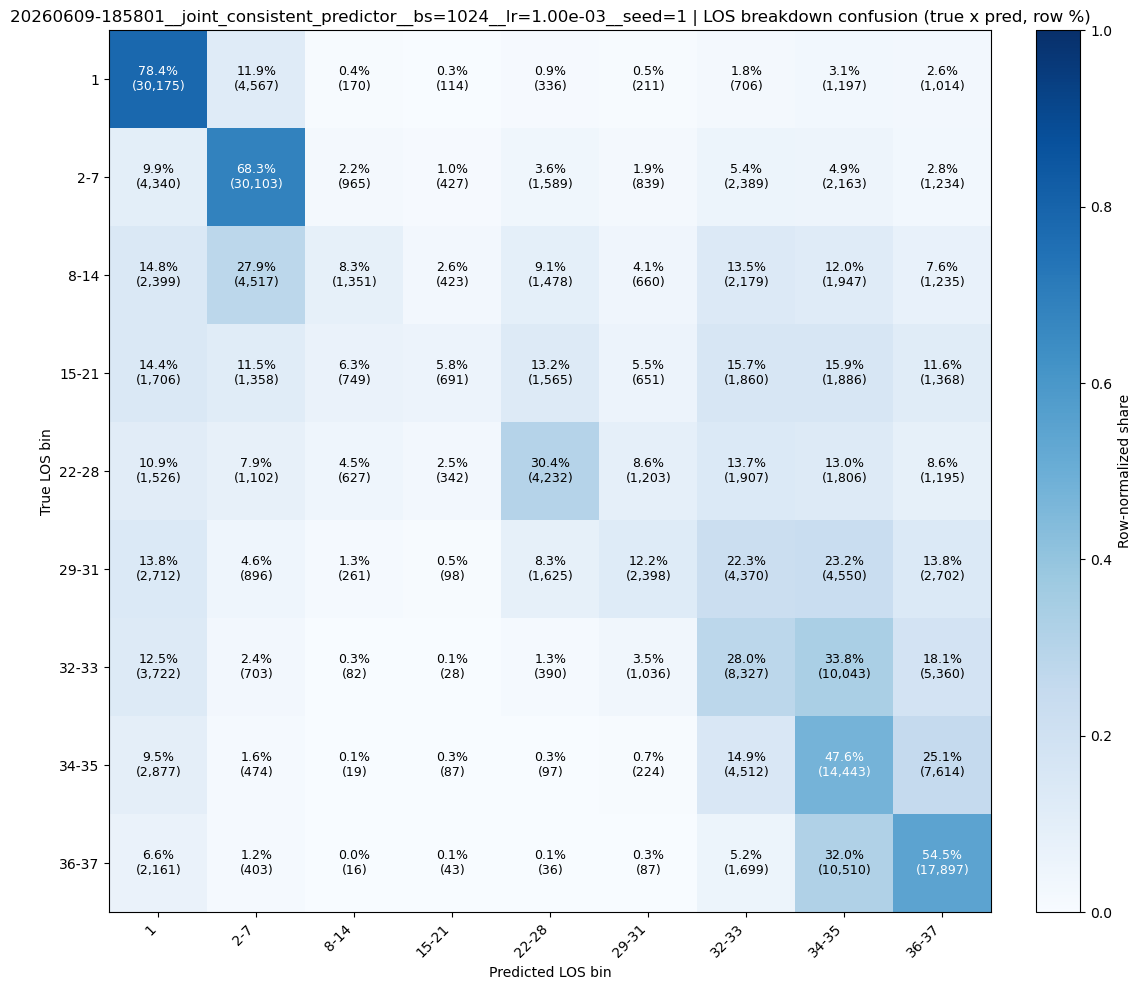

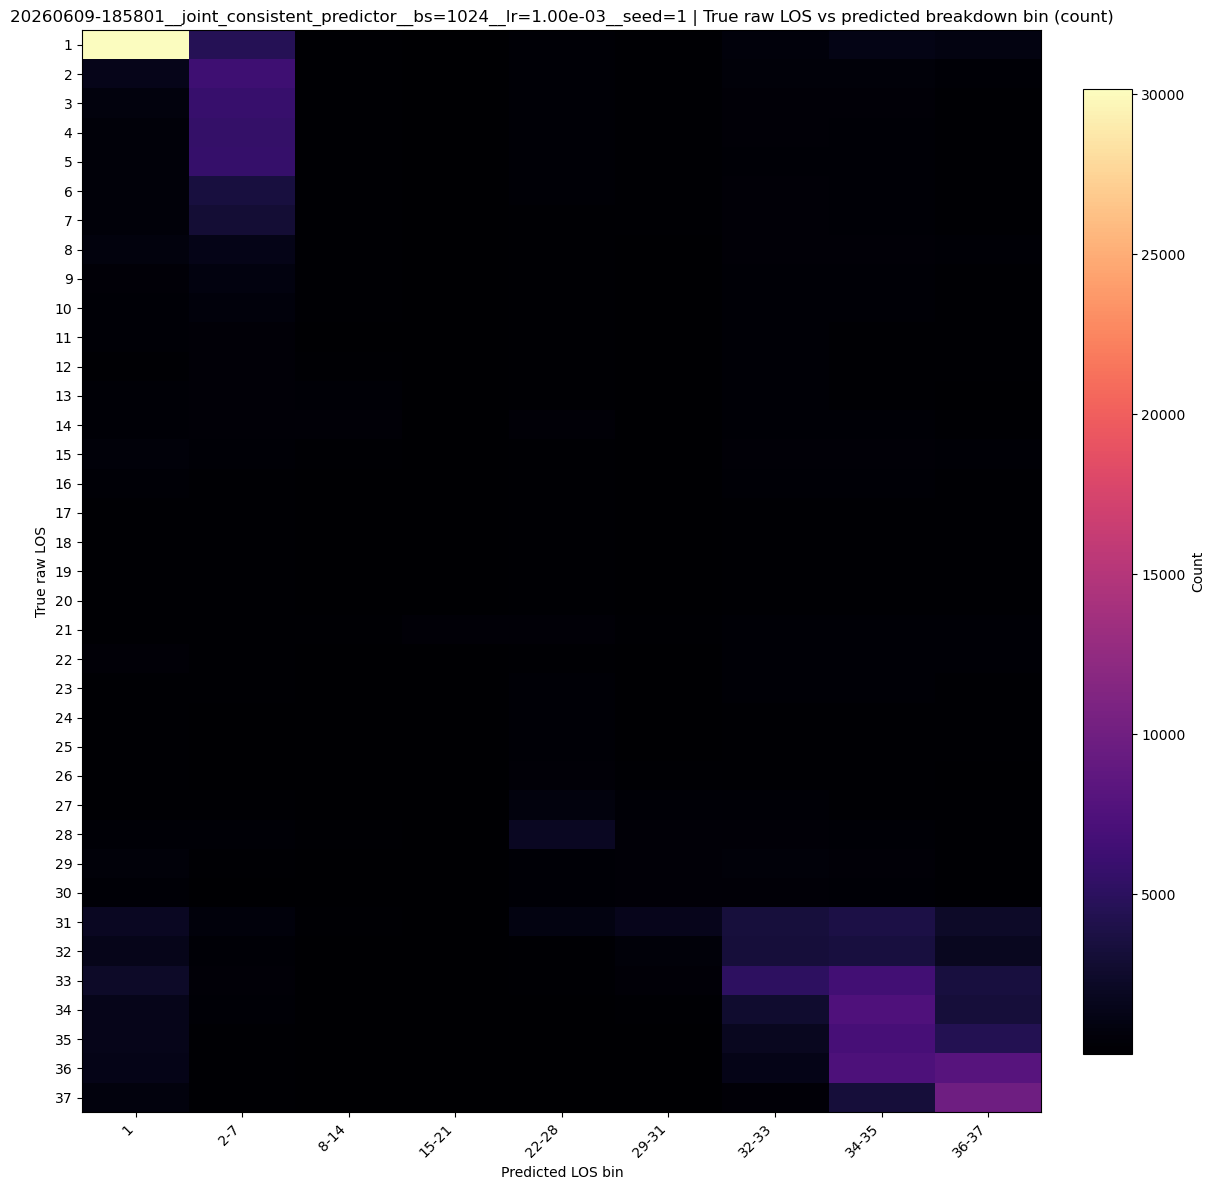

In [28]:
# LOS confusion matrix for 20260609-185801__joint_consistent_predictor__bs=1024__lr=1.00e-03__seed=1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

run_name = "20260609-185801__joint_consistent_predictor__bs=1024__lr=1.00e-03__seed=1"
pred_df = _get_predictions_df(run_name).copy()

breakdown_bins = [(1, 1), (2, 7), (8, 14), (15, 21), (22, 28), (29, 31), (32, 33), (34, 35), (36, 37)]
breakdown_labels = [str(lo) if lo == hi else f"{lo}-{hi}" for lo, hi in breakdown_bins]

def map_los_to_breakdown_bin(los: int) -> int:
    raw_los = int(los)
    for idx, (lo, hi) in enumerate(breakdown_bins):
        if lo <= raw_los <= hi:
            return idx
    raise ValueError(f"LOS must be in 1..37, got {los}.")

pred_df["true_los_breakdown"] = pred_df["true_los"].map(map_los_to_breakdown_bin)
pred_classes = sorted(pred_df["pred_los"].dropna().astype(int).unique())

expected_breakdown_classes = list(range(len(breakdown_bins)))
if pred_classes != expected_breakdown_classes:
    raise ValueError(
        f"Expected pred_los classes {expected_breakdown_classes} for breakdown LOS, got {pred_classes}."
    )

cm_breakdown = pd.crosstab(pred_df["true_los_breakdown"], pred_df["pred_los"])
cm_breakdown = cm_breakdown.reindex(index=expected_breakdown_classes, columns=expected_breakdown_classes, fill_value=0)
cm_breakdown.index = pd.Index(breakdown_labels, name="true_los_bin")
cm_breakdown.columns = pd.Index(breakdown_labels, name="pred_los_bin")
cm_breakdown_row_pct = cm_breakdown.div(cm_breakdown.sum(axis=1).replace(0, np.nan), axis=0)

display(cm_breakdown)
display((cm_breakdown_row_pct * 100).round(2))

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_breakdown_row_pct.fillna(0).to_numpy(), cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(breakdown_labels)), breakdown_labels, rotation=45, ha="right")
ax.set_yticks(np.arange(len(breakdown_labels)), breakdown_labels)
ax.set_xlabel("Predicted LOS bin")
ax.set_ylabel("True LOS bin")
ax.set_title(f"{run_name} | LOS breakdown confusion (true x pred, row %)")

for i in range(cm_breakdown.shape[0]):
    for j in range(cm_breakdown.shape[1]):
        pct = cm_breakdown_row_pct.iloc[i, j]
        count = cm_breakdown.iloc[i, j]
        label = "-" if pd.isna(pct) else f"{pct * 100:.1f}%\n({count:,})"
        color = "white" if (0 if pd.isna(pct) else pct) > 0.45 else "black"
        ax.text(j, i, label, ha="center", va="center", color=color, fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Row-normalized share")
plt.tight_layout()
plt.show()

cm_raw_to_breakdown = pd.crosstab(pred_df["true_los"], pred_df["pred_los"])
cm_raw_to_breakdown = cm_raw_to_breakdown.reindex(index=list(range(1, 38)), columns=expected_breakdown_classes, fill_value=0)
cm_raw_to_breakdown.columns = pd.Index(breakdown_labels, name="pred_los_bin")

fig, ax = plt.subplots(figsize=(12, 12))
im = ax.imshow(cm_raw_to_breakdown.to_numpy(), aspect="auto", cmap="magma")
ax.set_xticks(np.arange(len(breakdown_labels)), breakdown_labels, rotation=45, ha="right")
ax.set_yticks(np.arange(37), list(range(1, 38)))
ax.set_xlabel("Predicted LOS bin")
ax.set_ylabel("True raw LOS")
ax.set_title(f"{run_name} | True raw LOS vs predicted breakdown bin (count)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
plt.tight_layout()
plt.show()
